Notebook - Paléographie computationnelle.

# CNN

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import f1_score, accuracy_score
from pdf2image import convert_from_path

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    'train_dir': '/home/marty/Documents/ENC/Cours/paleographie/2. Torquato Tasso/1. Training dataset with images labeled as authentic or fake',
    'cache_dir': './processed_images_cache',
    'batch_size': 16, 
    'lr': 1e-4, 
    'epochs': 1,
    'seed': 42,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'patch_size': 224,
    'resize_short_edge': 1024 
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])
os.makedirs(CONFIG['cache_dir'], exist_ok=True)

# ==========================================
# 1. PRÉ-TRAITEMENT ET CACHE
# ==========================================
def preprocess_and_cache(base_dir, cache_dir):
    print(f"Vérification et conversion des fichiers dans {cache_dir}...")
    valid_files = []
    
    if not os.path.exists(base_dir):
        print(f"Le dossier {base_dir} n'existe pas. Vérifiez le chemin.")
        return valid_files

    raw_files = [f for f in os.listdir(base_dir) if f.startswith(('aut_', 'false_'))]
    
    for fname in tqdm(raw_files, desc="Préparation des données"):
        file_path = os.path.join(base_dir, fname)
        file_root, ext = os.path.splitext(fname)
        
        if ext.lower() == '.pdf':
            cached_file = os.path.join(cache_dir, file_root + ".jpg")
            if not os.path.exists(cached_file):
                try:
                    pages = convert_from_path(file_path, dpi=200, first_page=1, last_page=1)
                    pages[0].save(cached_file, 'JPEG')
                except Exception as e:
                    print(f"Erreur conversion {fname}: {e}")
                    continue
            final_path = cached_file
        else:
            final_path = file_path

        label = 1 if fname.startswith('aut_') else 0
        valid_files.append((final_path, label))
        
    return valid_files

files_labels = preprocess_and_cache(CONFIG['train_dir'], CONFIG['cache_dir'])
print(f"Total documents prêts : {len(files_labels)}")

# ==========================================
# 2. DATASET ET AUGMENTATION 
# ==========================================
class PaleoDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        try:
            image = Image.open(path).convert('RGB')
        except:
            image = Image.new('RGB', (1024, 1024))
            
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

# Normalisation standard ImageNet (requise pour ResNet)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# L'astuce est ici : On garde une image géante (1024) et on prend un patch aléatoire (224)
train_transforms = transforms.Compose([
    transforms.Resize(CONFIG['resize_short_edge']), 
    transforms.RandomCrop(CONFIG['patch_size']), 
    transforms.RandomRotation(degrees=5), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Pour la validation classique pendant l'entraînement, on prend le centre
val_transforms = transforms.Compose([
    transforms.Resize(CONFIG['resize_short_edge']),
    transforms.CenterCrop(CONFIG['patch_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

if len(files_labels) > 0:
    random.shuffle(files_labels)
    split_idx = int(0.8 * len(files_labels))
    train_data = files_labels[:split_idx]
    val_data = files_labels[split_idx:]

    train_ds = PaleoDataset(train_data, transform=train_transforms)
    val_ds = PaleoDataset(val_data, transform=val_transforms)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)

# ==========================================
# 3. MODÈLE (RESNET18 BACKBONE)
# ==========================================
print("Chargement du modèle CNN (ResNet18)...")
# On utilise les poids pré-entraînés officiels
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)


num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4), 
    nn.Linear(num_ftrs, 2)
)

model = model.to(CONFIG['device'])

# ==========================================
# 4. ENTRAÎNEMENT
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

best_acc = 0.0

if len(files_labels) > 0:
    print(f"Début de l'entraînement sur {CONFIG['device']}")
    
    for epoch in range(CONFIG['epochs']):
        # --- TRAIN ---
        model.train()
        train_loss = 0
        train_preds, train_targets = [], []
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]")
        for images, labels in loop:
            images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())
            
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION ---
        model.eval()
        val_loss = 0
        val_preds, val_targets = [] , []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        train_acc = accuracy_score(train_targets, train_preds)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='weighted', zero_division=0)
        avg_val_loss = val_loss / len(val_loader)
        
        if val_acc > best_acc:
            best_acc = val_acc
            save_path = os.path.join(CONFIG['train_dir'], 'best_resnet_paleo.pth')
            # Commenté par sécurité si le dossier n'existe pas, à décommenter en prod
            # torch.save(model.state_dict(), save_path)
            print(f"Modèle sauvegardé ! (New Best Acc: {best_acc:.4f})")
        
        scheduler.step(avg_val_loss)

        print(f"Fin Epoch {epoch+1}: Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# ==========================================
# 5. INFÉRENCE SUR UNE PAGE COMPLÈTE (VOTE À LA MAJORITÉ)
# ==========================================
def predict_page_majority_vote(image_path, model, device, patch_size=224, stride=224):
    """
    Découpe une image haute résolution en une grille de patches, 
    prédit sur chaque patch, et retourne le vote majoritaire.
    """
    model.eval()
    
    # 1. Charger et préparer l'image
    img = Image.open(image_path).convert('RGB')
    
    
    w, h = img.size
    aspect_ratio = w / h
    if w < h:
        new_w = CONFIG['resize_short_edge']
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = CONFIG['resize_short_edge']
        new_w = int(new_h * aspect_ratio)
    img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    
    # Transformer de base (juste ToTensor et Normalize)
    base_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])
    
    img_tensor = base_transform(img).unsqueeze(0).to(device) # Shape: [1, 3, H, W]
    
    # 2. Extraire les patches avec la technique de la fenêtre glissante (Unfold)
    # C'est beaucoup plus rapide que de faire une boucle for sur l'image PIL
    kc, kh, kw = 3, patch_size, patch_size
    dc, dh, dw = 3, stride, stride 
    
    # On utilise unfold pour créer les patches
    patches = img_tensor.unfold(2, kh, dh).unfold(3, kw, dw)
    patches = patches.contiguous().view(1, 3, -1, kh, kw)
    patches = patches.permute(2, 0, 1, 3, 4).squeeze(1) 
    
    print(f"Analyse de la page en {patches.shape[0]} patches...")
    
   
    with torch.no_grad():
        
        outputs = model(patches)
        probabilities = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
    # 4. Calcul du vote
    nb_fake = (preds == 0).sum().item()
    nb_aut = (preds == 1).sum().item()
    total = patches.shape[0]
    
    print(f"Résultats du vote : {nb_aut} Autenthique(s) | {nb_fake} Faux")
    
    if nb_aut > nb_fake:
        confidence = nb_aut / total * 100
        return f"AUTHENTIQUE (Confiance : {confidence:.1f}%)"
    else:
        confidence = nb_fake / total * 100
        return f"FAUX (Confiance : {confidence:.1f}%)"


🔄 Vérification et conversion des fichiers dans ./processed_images_cache...


Préparation des données:   0%|          | 0/530 [00:00<?, ?it/s]

✅ Total documents prêts : 530
Chargement du modèle CNN (ResNet18)...
Début de l'entraînement sur cpu


/home/marty/miniconda3/envs/enc+/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/1 [Train]:   0%|          | 0/27 [00:00<?, ?it/s]

Modèle sauvegardé ! (New Best Acc: 0.9811)
Fin Epoch 1: Train Acc: 0.8797 | Val Loss: 0.0764 | Val Acc: 0.9811 | Val F1: 0.9811


CLIP


════════════════════════════════════════════════════════════
  ÉTAPE 1 — Construction du cache
════════════════════════════════════════════════════════════
📂 530 fichiers sources détectés.


🔄 Construction du cache:   0%|          | 0/530 [00:00<?, ?it/s]

✅ Cache prêt : 530 documents
   Authentiques : 302 | Faux : 228

════════════════════════════════════════════════════════════
  ÉTAPE 2 — Préparation des DataLoaders
════════════════════════════════════════════════════════════

📊 Split : 425 train | 105 val

════════════════════════════════════════════════════════════
  ÉTAPE 3 — Initialisation du modèle Dual-Stream CLIP
════════════════════════════════════════════════════════════
  Chargement openai/clip-vit-base-patch32...
  Paramètres entraînables : 87,949,892

════════════════════════════════════════════════════════════
  ÉTAPE 4 — Entraînement
════════════════════════════════════════════════════════════

🚀 Entraînement sur cpu — 2 époques
──────────────────────────────────────────────────────────────────────


  Train:   0%|          | 0/107 [00:00<?, ?it/s]

Ep 01/2 │ Train Loss 0.3574  Acc 0.873 │ Val Loss 0.2308  Acc 0.962  F1 0.962 │ Gate [couleur 60% | trait 40%]
  ✅ Nouveau meilleur modèle sauvegardé (F1=0.9618)


  Train:   0%|          | 0/107 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f9168f8dc60>
Traceback (most recent call last):
  File "/home/marty/miniconda3/envs/enc+/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/home/marty/miniconda3/envs/enc+/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
  File "/home/marty/miniconda3/envs/enc+/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f9168f8dc60>
Traceback (most recent call last):
  File "/home/marty/miniconda3/envs/enc+/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/home/marty/miniconda3/envs/enc+/lib/python3.10/s

Ep 02/2 │ Train Loss 0.2954  Acc 0.944 │ Val Loss 0.2543  Acc 0.962  F1 0.962 │ Gate [couleur 61% | trait 39%]
──────────────────────────────────────────────────────────────────────
✅ Entraînement terminé. Meilleur F1 val : 0.9618

════════════════════════════════════════════════════════════
  ÉTAPE 5 — Rapport final (meilleur modèle)
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  RAPPORT DE VALIDATION FINAL
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

        FAUX     0.9767    0.9333    0.9545        45
 AUTHENTIQUE     0.9516    0.9833    0.9672        60

    accuracy                         0.9619       105
   macro avg     0.9642    0.9583    0.9609       105
weighted avg     0.9624    0.9619    0.9618       105

Matrice de confusion :
[[42  3]
 [ 1 59]]

Acc : 0.9619  |  F1 : 0.9618

Attention Gate (moyenne val) :
  Flux Couleur : 6

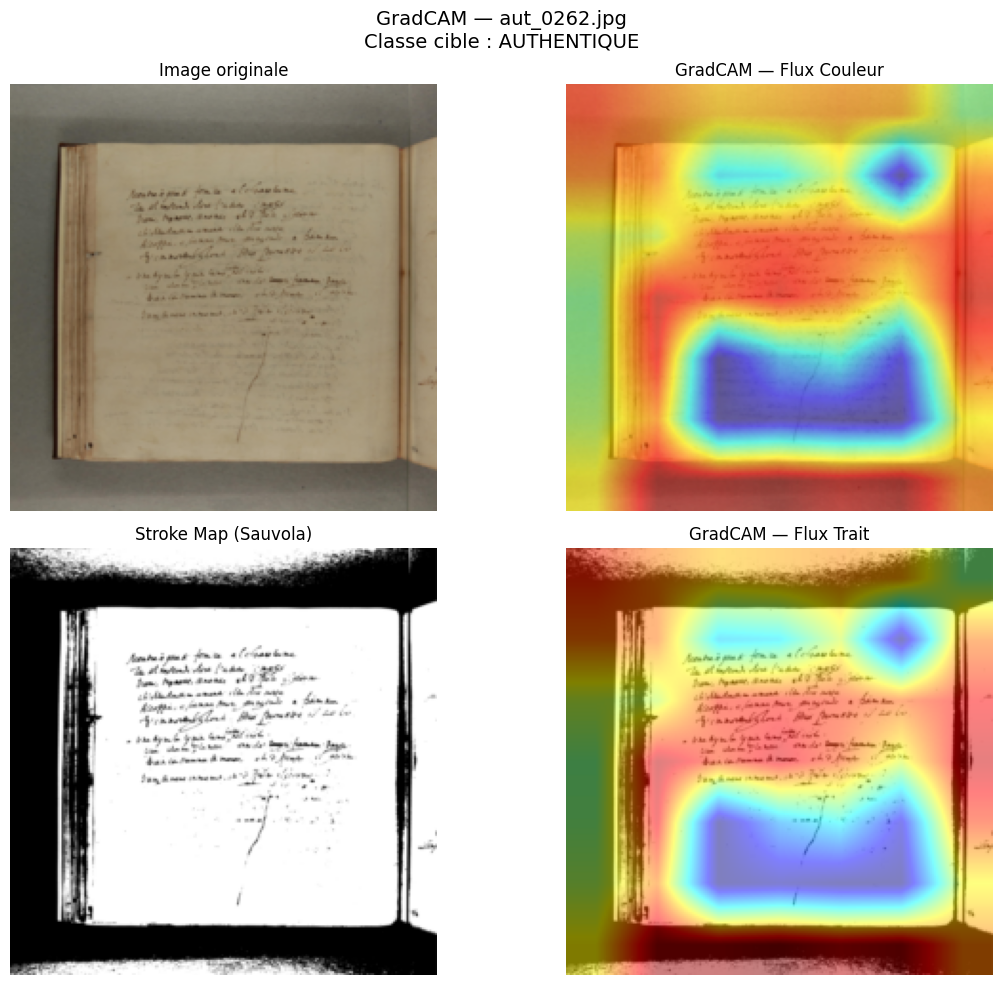


════════════════════════════════════════════════════════════
  ÉTAPE 7 — Exemple d'inférence
════════════════════════════════════════════════════════════

  Fichier   : aut_0262.jpg
  Décision  : AUTHENTIQUE  (confiance 98.2%)
  P(faux)   : 1.8%
  P(auth)   : 98.2%
  Gate      : couleur 59%  |  trait 41%



In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║         PALÉOGRAPHIE — AUTHENTICATOR DUAL-STREAM CLIP                      ║
║         Classification manuscrit authentique / faux                         ║
║         Focus : morphologie des lettres (ductus), pas le support            ║
╚══════════════════════════════════════════════════════════════════════════════╝

Architecture :
  ┌─────────────────┐     ┌──────────────────┐
  │  Image couleur  │     │  Stroke Map (bin) │
  │  (contexte)     │     │  (ductus pur)     │
  └────────┬────────┘     └────────┬──────────┘
           │                       │
     CLIP-ViT encoder        CLIP-ViT encoder   (poids partagés)
           │                       │
      proj_color (256)       proj_stroke (256)
           └──────────┬────────────┘
                 Attention Gate
                      │
               Classifier (512→128→2)
                      │
            [Authentique / Faux]

Dépendances :
    pip install torch torchvision transformers scikit-image
    pip install grad-cam pillow tqdm scikit-learn pdf2image
"""

import os
import random
import warnings
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from PIL import Image, ImageFilter, ImageOps
from transformers import CLIPVisionModel

from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — tout est centralisé ici
# ══════════════════════════════════════════════════════════════════════════════
CONFIG = {
    # ── Chemins ──────────────────────────────────────────────────────────────
    'train_dir': (
        '/home/marty/Documents/ENC/Cours/paleographie/2. Torquato Tasso/1. Training dataset with images labeled as authentic or fake'
    ),
    'cache_dir':  './cache_multi/tasso',

    # ── Entraînement ─────────────────────────────────────────────────────────
    'batch_size':   4,
    'lr':           3e-5,
    'weight_decay': 1e-4,
    'epochs':       2,
    'val_split':    0.2,
    'seed':         42,

    # ── Résolution ───────────────────────────────────────────────────────────
    'input_size':   224,   # taille finale pour CLIP

    # ── Binarisation Sauvola ─────────────────────────────────────────────────
    'sauvola_window': 31,   # plus grand = fond plus uniforme (bon pour parchemin)
    'sauvola_k':      0.15,

    # ── Modèle ───────────────────────────────────────────────────────────────
    'clip_model': 'openai/clip-vit-base-patch32',
    'num_classes': 2,
    'dropout':     0.4,
    'proj_dim':    256,

    # ── Inférence ────────────────────────────────────────────────────────────
    'tta_n': 5,   # Test-Time Augmentation : nombre de passes

    # ── Device ───────────────────────────────────────────────────────────────
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
}

CLIP_MEAN = [0.48145466, 0.4578275,  0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

CLASS_NAMES = {0: 'FAUX', 1: 'AUTHENTIQUE'}


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])


# ══════════════════════════════════════════════════════════════════════════════
# 1. PRÉ-TRAITEMENT — STROKE MAP (cœur du projet)
# ══════════════════════════════════════════════════════════════════════════════

def extract_stroke_map(img_pil: Image.Image) -> Image.Image:
    """
    Extrait uniquement les traits calligraphiques par binarisation Sauvola.

    Sauvola est supérieur à Otsu sur les manuscrits car il s'adapte
    localement aux variations de fond (parchemin jauni, taches d'encre,
    ondulations du support).

    Retourne une image RGB : traits noirs sur fond blanc.
    """
    gray_np = np.array(img_pil.convert('L'), dtype=np.float32)

    # ── Binarisation Sauvola ─────────────────────────────────────────────────
    try:
        from skimage.filters import threshold_sauvola
        thresh = threshold_sauvola(
            gray_np,
            window_size=CONFIG['sauvola_window'],
            k=CONFIG['sauvola_k']
        )
        binary = gray_np < thresh  # True = encre (sombre)
    except ImportError:
        # Fallback : seuil adaptatif global si scikit-image absent
        percentile = np.percentile(gray_np, 35)
        binary = gray_np < percentile

    # ── Post-traitement morphologique ────────────────────────────────────────
    # Convertit en uint8 : traits = 0 (noir), fond = 255 (blanc)
    stroke_uint8 = ((~binary) * 255).astype(np.uint8)
    stroke_pil   = Image.fromarray(stroke_uint8, mode='L')

    # Supprime le bruit de scan (petits artefacts) sans épaissir les traits
    stroke_pil = stroke_pil.filter(ImageFilter.MedianFilter(size=3))

    return stroke_pil.convert('RGB')


def remove_background(img_pil: Image.Image) -> Image.Image:
    """
    Neutralise le fond (parchemin, papier jauni) en gris neutre.
    Détruit le biais colorimétrique du support sans toucher les traits.
    """
    gray   = np.array(img_pil.convert('L'))
    thresh = np.percentile(gray, 65)  # 65% des pixels = fond

    img_arr = np.array(img_pil).copy()
    mask    = gray > thresh
    img_arr[mask] = [160, 155, 148]   # gris pierre : neutre, pas blanc pur

    return Image.fromarray(img_arr)


# ══════════════════════════════════════════════════════════════════════════════
# 2. CACHE — conversion PDF + génération stroke maps
# ══════════════════════════════════════════════════════════════════════════════

def build_cache(base_dir: str, cache_dir: str) -> list:
    """
    Pour chaque fichier source :
      - Convertit les PDF en JPEG (1ère page, 200 dpi)
      - Génère la stroke map (binarisation Sauvola)
      - Retourne [(color_path, stroke_path, label), ...]
    """
    os.makedirs(os.path.join(cache_dir, 'color'),  exist_ok=True)
    os.makedirs(os.path.join(cache_dir, 'strokes'), exist_ok=True)

    dataset = []
    raw_files = sorted([
        f for f in os.listdir(base_dir)
        if f.lower().startswith(('aut_', 'false_'))
    ])

    if not raw_files:
        raise FileNotFoundError(
            f"Aucun fichier aut_* ou false_* trouvé dans {base_dir}"
        )

    print(f"📂 {len(raw_files)} fichiers sources détectés.")

    for fname in tqdm(raw_files, desc="🔄 Construction du cache"):
        src      = os.path.join(base_dir, fname)
        stem, ext = os.path.splitext(fname)
        label    = 1 if fname.lower().startswith('aut_') else 0

        # ── Résolution image couleur ─────────────────────────────────────────
        color_path = os.path.join(cache_dir, 'color', stem + '.jpg')
        if not os.path.exists(color_path):
            try:
                if ext.lower() == '.pdf':
                    from pdf2image import convert_from_path
                    pages = convert_from_path(src, dpi=200, first_page=1, last_page=1)
                    img   = pages[0].convert('RGB')
                else:
                    img = Image.open(src).convert('RGB')
                img.save(color_path, 'JPEG', quality=95)
            except Exception as e:
                print(f"  ⚠️  Erreur {fname}: {e}")
                continue

        # ── Génération stroke map ────────────────────────────────────────────
        stroke_path = os.path.join(cache_dir, 'strokes', stem + '_stroke.png')
        if not os.path.exists(stroke_path):
            try:
                img    = Image.open(color_path).convert('RGB')
                stroke = extract_stroke_map(img)
                stroke.save(stroke_path, 'PNG')
            except Exception as e:
                print(f"  ⚠️  Stroke map échouée {fname}: {e}")
                stroke_path = color_path  # fallback

        dataset.append((color_path, stroke_path, label))

    print(f"✅ Cache prêt : {len(dataset)} documents")
    n_auth = sum(1 for _, _, l in dataset if l == 1)
    n_fake = len(dataset) - n_auth
    print(f"   Authentiques : {n_auth} | Faux : {n_fake}")

    return dataset


# ══════════════════════════════════════════════════════════════════════════════
# 3. TRANSFORMS — colour stream + stroke stream
# ══════════════════════════════════════════════════════════════════════════════

def get_transforms(mode: str = 'train'):
    """
    color  : image couleur avec fond neutralisé + augmentations légères
    stroke : stroke map binarisée, seules rotations/flips légers autorisés
    """
    sz = CONFIG['input_size']

    if mode == 'train':
        color_tf = transforms.Compose([
            transforms.Resize((sz + 32, sz + 32)),
            transforms.RandomCrop(sz),
            transforms.Lambda(remove_background),       # fond neutre
            transforms.RandomRotation(degrees=6),
            transforms.ColorJitter(
                brightness=0.25, contrast=0.3, saturation=0.05
            ),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8)),
            transforms.ToTensor(),
            transforms.Normalize(CLIP_MEAN, CLIP_STD),
        ])
        stroke_tf = transforms.Compose([
            transforms.Resize((sz + 32, sz + 32)),
            transforms.RandomCrop(sz),
            transforms.RandomRotation(degrees=6),
            transforms.ToTensor(),
            transforms.Normalize(CLIP_MEAN, CLIP_STD),
        ])
    else:  # val / test
        color_tf = transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.Lambda(remove_background),
            transforms.ToTensor(),
            transforms.Normalize(CLIP_MEAN, CLIP_STD),
        ])
        stroke_tf = transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.ToTensor(),
            transforms.Normalize(CLIP_MEAN, CLIP_STD),
        ])

    return color_tf, stroke_tf


# ══════════════════════════════════════════════════════════════════════════════
# 4. DATASET
# ══════════════════════════════════════════════════════════════════════════════

class DualStreamDataset(Dataset):
    def __init__(self, data: list, color_tf, stroke_tf):
        """
        data : [(color_path, stroke_path, label), ...]
        """
        self.data      = data
        self.color_tf  = color_tf
        self.stroke_tf = stroke_tf

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        color_path, stroke_path, label = self.data[idx]

        try:
            img_color  = Image.open(color_path).convert('RGB')
        except Exception:
            img_color  = Image.new('RGB', (224, 224), color=(160, 155, 148))

        try:
            img_stroke = Image.open(stroke_path).convert('RGB')
        except Exception:
            img_stroke = Image.new('RGB', (224, 224), color=(255, 255, 255))

        return (
            self.color_tf(img_color),
            self.stroke_tf(img_stroke),
            torch.tensor(label, dtype=torch.long),
        )


def make_weighted_sampler(data: list) -> WeightedRandomSampler:
    """
    Rééquilibre le dataset si les classes sont déséquilibrées.
    Évite que le modèle apprenne à prédire la majorité par défaut.
    """
    labels   = [l for _, _, l in data]
    counts   = np.bincount(labels)
    weights  = 1.0 / counts
    sample_w = [weights[l] for l in labels]
    return WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)


def build_dataloaders(dataset: list, val_split: float = 0.2):
    """Split stratifié train/val + DataLoaders."""
    # Split stratifié (même proportion auth/faux dans train et val)
    auth  = [x for x in dataset if x[2] == 1]
    fake  = [x for x in dataset if x[2] == 0]
    random.shuffle(auth)
    random.shuffle(fake)

    def split(lst):
        n = max(1, int(len(lst) * val_split))
        return lst[n:], lst[:n]

    train_a, val_a = split(auth)
    train_f, val_f = split(fake)

    train_data = train_a + train_f
    val_data   = val_a   + val_f
    random.shuffle(train_data)

    color_train, stroke_train = get_transforms('train')
    color_val,   stroke_val   = get_transforms('val')

    train_ds = DualStreamDataset(train_data, color_train, stroke_train)
    val_ds   = DualStreamDataset(val_data,   color_val,   stroke_val)

    sampler = make_weighted_sampler(train_data)

    train_loader = DataLoader(
        train_ds, batch_size=CONFIG['batch_size'],
        sampler=sampler, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=CONFIG['batch_size'],
        shuffle=False, num_workers=2, pin_memory=True
    )

    print(f"\n📊 Split : {len(train_data)} train | {len(val_data)} val")
    return train_loader, val_loader, train_data, val_data


# ══════════════════════════════════════════════════════════════════════════════
# 5. MODÈLE — Dual-Stream CLIP + Attention Gate
# ══════════════════════════════════════════════════════════════════════════════

class DualStreamPaleoCLIP(nn.Module):
    """
    Deux flux CLIP-ViT à poids partagés + fusion par Attention Gate.

    Le weight sharing (poids partagés) est un choix délibéré :
      - Réduit le nombre de paramètres (essentiel avec peu de données)
      - Force l'encodeur à être polyvalent (couleur ET traits binaires)
      - Régularise naturellement l'entraînement

    L'Attention Gate apprend à pondérer les deux flux :
      - Si le fond est trompeur  → ↑ poids stroke
      - Si la stroke map est bruit → ↑ poids couleur
    """

    def __init__(self):
        super().__init__()
        num_classes = CONFIG['num_classes']
        proj_dim    = CONFIG['proj_dim']
        dropout     = CONFIG['dropout']

        # ── Backbone CLIP partagé ─────────────────────────────────────────────
        print(f"  Chargement {CONFIG['clip_model']}...")
        self.backbone = CLIPVisionModel.from_pretrained(CONFIG['clip_model'])
        hidden = self.backbone.config.hidden_size  # 768 pour ViT-B/32

        # ── Projections indépendantes par flux ───────────────────────────────
        self.proj_color = nn.Sequential(
            nn.Linear(hidden, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        self.proj_stroke = nn.Sequential(
            nn.Linear(hidden, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )

        # ── Attention Gate ────────────────────────────────────────────────────
        # Apprend l'importance relative des deux flux image par image
        self.gate = nn.Sequential(
            nn.Linear(proj_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1),
        )

        # ── Tête de classification ────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Encodage CLIP → vecteur pooled (B, hidden)."""
        return self.backbone(pixel_values=x).pooler_output

    def forward(self, x_color: torch.Tensor, x_stroke: torch.Tensor):
        # 1. Encodage des deux flux
        feat_c = self.proj_color(self.encode(x_color))    # (B, proj_dim)
        feat_s = self.proj_stroke(self.encode(x_stroke))  # (B, proj_dim)

        # 2. Attention gate : poids appris w0, w1 ∈ [0,1], w0+w1=1
        combined = torch.cat([feat_c, feat_s], dim=1)     # (B, proj_dim*2)
        weights  = self.gate(combined)                     # (B, 2)

        # 3. Fusion pondérée + concaténation (richesse représentationnelle)
        fused = (
            weights[:, 0:1] * feat_c +
            weights[:, 1:2] * feat_s
        )                                                  # (B, proj_dim)
        fusion_repr = torch.cat([fused, combined], dim=1) # (B, proj_dim*3)

        # On utilise combined (plus stable en début d'entraînement)
        logits = self.classifier(combined)                 # (B, num_classes)
        return logits, weights  # retourne les poids pour analyse / debug


# ══════════════════════════════════════════════════════════════════════════════
# 6. ENTRAÎNEMENT
# ══════════════════════════════════════════════════════════════════════════════

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_targets = [], []

    loop = tqdm(loader, desc="  Train", leave=False)
    for x_c, x_s, labels in loop:
        x_c, x_s, labels = x_c.to(device), x_s.to(device), labels.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_c, x_s)
        loss      = criterion(logits, labels)
        loss.backward()

        # Gradient clipping (stabilité sur petit dataset)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        loop.set_postfix(loss=f"{loss.item():.4f}")

    acc = accuracy_score(all_targets, all_preds)
    return total_loss / len(loader), acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    all_weights = []

    for x_c, x_s, labels in loader:
        x_c, x_s, labels = x_c.to(device), x_s.to(device), labels.to(device)
        logits, weights   = model(x_c, x_s)
        loss              = criterion(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        all_weights.append(weights.cpu().numpy())

    all_weights = np.vstack(all_weights)
    acc = accuracy_score(all_targets, all_preds)
    f1  = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

    # Affiche le poids moyen accordé à chaque flux
    mean_w = all_weights.mean(axis=0)

    return total_loss / len(loader), acc, f1, mean_w, all_preds, all_targets


def train(model, train_loader, val_loader, save_path: str):
    device    = CONFIG['device']
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay']
    )
    # Cosine annealing : descend doucement, évite le surapprentissage
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG['epochs'], eta_min=1e-6
    )

    best_f1   = 0.0
    patience  = 4    # early stopping
    no_improve = 0

    print(f"\n🚀 Entraînement sur {device} — {CONFIG['epochs']} époques")
    print("─" * 70)

    for epoch in range(1, CONFIG['epochs'] + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc, val_f1, gate_w, _, _ = evaluate(
            model, val_loader, criterion, device
        )
        scheduler.step()

        # Affichage poids du gate (interprétabilité)
        gw_color  = gate_w[0] * 100
        gw_stroke = gate_w[1] * 100

        print(
            f"Ep {epoch:02d}/{CONFIG['epochs']} │ "
            f"Train Loss {train_loss:.4f}  Acc {train_acc:.3f} │ "
            f"Val Loss {val_loss:.4f}  Acc {val_acc:.3f}  F1 {val_f1:.3f} │ "
            f"Gate [couleur {gw_color:.0f}% | trait {gw_stroke:.0f}%]"
        )

        if val_f1 > best_f1:
            best_f1    = val_f1
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✅ Nouveau meilleur modèle sauvegardé (F1={best_f1:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  ⏹  Early stopping (pas d'amélioration depuis {patience} époques)")
                break

    print("─" * 70)
    print(f"✅ Entraînement terminé. Meilleur F1 val : {best_f1:.4f}")
    return best_f1


# ══════════════════════════════════════════════════════════════════════════════
# 7. INFÉRENCE AVEC TEST-TIME AUGMENTATION (TTA)
# ══════════════════════════════════════════════════════════════════════════════

def predict_single(
    image_path: str,
    model: nn.Module,
    device,
    tta_n: int = None
) -> dict:
    """
    Prédit si un manuscrit est authentique ou faux.

    TTA (Test-Time Augmentation) : on fait N passes avec des transformations
    légèrement différentes et on moyenne les probabilités → plus robuste.

    Retourne un dict avec label prédit, probabilités et confiance.
    """
    from pdf2image import convert_from_path  # import local au cas où absent

    tta_n = tta_n or CONFIG['tta_n']
    model.eval()

    # ── Chargement image ─────────────────────────────────────────────────────
    _, ext = os.path.splitext(image_path)
    if ext.lower() == '.pdf':
        pages   = convert_from_path(image_path, dpi=200, first_page=1, last_page=1)
        img_pil = pages[0].convert('RGB')
    else:
        img_pil = Image.open(image_path).convert('RGB')

    # ── Stroke map ───────────────────────────────────────────────────────────
    stroke_pil = extract_stroke_map(img_pil)

    # ── TTA transforms (légères) ─────────────────────────────────────────────
    sz = CONFIG['input_size']
    tta_color_tf = transforms.Compose([
        transforms.Resize((sz + 16, sz + 16)),
        transforms.RandomCrop(sz),
        transforms.Lambda(remove_background),
        transforms.RandomRotation(degrees=4),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD),
    ])
    tta_stroke_tf = transforms.Compose([
        transforms.Resize((sz + 16, sz + 16)),
        transforms.RandomCrop(sz),
        transforms.RandomRotation(degrees=4),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD),
    ])

    # ── Passes TTA ───────────────────────────────────────────────────────────
    all_probs = []
    all_gates = []

    with torch.no_grad():
        for _ in range(tta_n):
            x_c = tta_color_tf(img_pil).unsqueeze(0).to(device)
            x_s = tta_stroke_tf(stroke_pil).unsqueeze(0).to(device)
            logits, weights = model(x_c, x_s)
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
            all_probs.append(probs)
            all_gates.append(weights.cpu().numpy()[0])

    mean_probs = np.mean(all_probs, axis=0)
    mean_gates = np.mean(all_gates, axis=0)
    pred_label = int(np.argmax(mean_probs))

    return {
        'label':        CLASS_NAMES[pred_label],
        'label_id':     pred_label,
        'prob_faux':    float(mean_probs[0]),
        'prob_auth':    float(mean_probs[1]),
        'confidence':   float(mean_probs[pred_label]),
        'gate_color':   float(mean_gates[0]),
        'gate_stroke':  float(mean_gates[1]),
    }


# ══════════════════════════════════════════════════════════════════════════════
# 8. GRADCAM — Visualisation de ce que le modèle regarde
# ══════════════════════════════════════════════════════════════════════════════

def reshape_transform_vit(tensor, height=7, width=7):
    """Adapte les feature maps de ViT (séquence de patches) pour GradCAM."""
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)


def generate_gradcam(image_path: str, model: nn.Module, device, target_class: int = 1):
    """
    Génère deux heatmaps GradCAM côte à côte :
      - Sur le flux couleur (est-ce que le modèle regarde le fond ?)
      - Sur le flux stroke (est-ce qu'il regarde les traits ?)

    À utiliser pour valider que le modèle est bien focalisé sur le ductus.
    """
    try:
        from pytorch_grad_cam import GradCAM
        from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
        from pytorch_grad_cam.utils.image import show_cam_on_image
    except ImportError:
        print("❌ Installez : pip install grad-cam")
        return

    import matplotlib.pyplot as plt
    from pdf2image import convert_from_path

    # ── Chargement ────────────────────────────────────────────────────────────
    _, ext = os.path.splitext(image_path)
    if ext.lower() == '.pdf':
        pages   = convert_from_path(image_path, dpi=200, first_page=1, last_page=1)
        img_pil = pages[0].convert('RGB')
    else:
        img_pil = Image.open(image_path).convert('RGB')

    stroke_pil = extract_stroke_map(img_pil)
    sz         = CONFIG['input_size']

    preprocess_base = transforms.Resize((sz, sz))
    img_resized   = preprocess_base(img_pil)
    stroke_resized = preprocess_base(stroke_pil)

    to_float = lambda x: np.float32(x) / 255.0

    tensor_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD),
    ])
    x_c = tensor_tf(img_resized).unsqueeze(0).to(device)
    x_s = tensor_tf(stroke_resized).unsqueeze(0).to(device)

    # ── Wrapper pour GradCAM sur un seul flux ──────────────────────────────
    class ColorWrapper(nn.Module):
        def __init__(self, m, x_s):
            super().__init__()
            self.m   = m
            self.x_s = x_s
        def forward(self, x):
            logits, _ = self.m(x, self.x_s)
            return logits

    class StrokeWrapper(nn.Module):
        def __init__(self, m, x_c):
            super().__init__()
            self.m   = m
            self.x_c = x_c
        def forward(self, x):
            logits, _ = self.m(self.x_c, x)
            return logits

    target_layer_path = model.backbone.vision_model.encoder.layers[-1].layer_norm1
    targets           = [ClassifierOutputTarget(target_class)]

    def compute_cam(wrapper, input_t):
        cam = GradCAM(
            model=wrapper,
            target_layers=[target_layer_path],
            reshape_transform=reshape_transform_vit,
        )
        gc = cam(input_tensor=input_t, targets=targets)
        return gc[0]

    model.eval()
    cam_color  = compute_cam(ColorWrapper(model, x_s),  x_c)
    cam_stroke = compute_cam(StrokeWrapper(model, x_c), x_s)

    viz_color  = show_cam_on_image(to_float(img_resized),    cam_color,  use_rgb=True)
    viz_stroke = show_cam_on_image(to_float(stroke_resized), cam_stroke, use_rgb=True)

    # ── Affichage ─────────────────────────────────────────────────────────────
    label_name  = CLASS_NAMES[target_class]
    fname       = os.path.basename(image_path)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(
        f"GradCAM — {fname}\nClasse cible : {label_name}", fontsize=14
    )

    axes[0, 0].imshow(to_float(img_resized));    axes[0, 0].set_title("Image originale")
    axes[0, 1].imshow(viz_color);                axes[0, 1].set_title("GradCAM — Flux Couleur")
    axes[1, 0].imshow(to_float(stroke_resized)); axes[1, 0].set_title("Stroke Map (Sauvola)")
    axes[1, 1].imshow(viz_stroke);               axes[1, 1].set_title("GradCAM — Flux Trait")

    for ax in axes.flat:
        ax.axis('off')

    plt.tight_layout()
    out = os.path.join(
        CONFIG['cache_dir'],
        f"gradcam_{os.path.splitext(fname)[0]}_{label_name}.png"
    )
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f"  💾 Heatmap sauvegardée : {out}")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 9. RAPPORT DE VALIDATION FINAL
# ══════════════════════════════════════════════════════════════════════════════

def final_validation_report(model, val_loader, device):
    """Rapport complet après entraînement."""
    criterion = nn.CrossEntropyLoss()
    _, acc, f1, gate_w, preds, targets = evaluate(
        model, val_loader, criterion, device
    )

    print("\n" + "═" * 60)
    print("  RAPPORT DE VALIDATION FINAL")
    print("═" * 60)
    print(classification_report(
        targets, preds,
        target_names=['FAUX', 'AUTHENTIQUE'],
        digits=4
    ))
    cm = confusion_matrix(targets, preds)
    print(f"Matrice de confusion :\n{cm}")
    print(f"\nAcc : {acc:.4f}  |  F1 : {f1:.4f}")
    print(
        f"\nAttention Gate (moyenne val) :\n"
        f"  Flux Couleur : {gate_w[0]*100:.1f}%\n"
        f"  Flux Traits  : {gate_w[1]*100:.1f}%"
    )
    if gate_w[1] > gate_w[0]:
        print("\n  ✅ Le modèle se focalise principalement sur les traits calligraphiques.")
    else:
        print("\n  ⚠️  Le modèle se focalise encore sur la couleur — vérifier GradCAM.")
    print("═" * 60)


# ══════════════════════════════════════════════════════════════════════════════
# 10. MAIN
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == '__main__':

    os.makedirs(CONFIG['cache_dir'], exist_ok=True)
    SAVE_PATH = os.path.join(CONFIG['cache_dir'], 'best_dual_stream.pth')

    # ── Étape 1 : Cache ───────────────────────────────────────────────────────
    print("\n" + "═" * 60)
    print("  ÉTAPE 1 — Construction du cache")
    print("═" * 60)
    dataset = build_cache(CONFIG['train_dir'], CONFIG['cache_dir'])

    # ── Étape 2 : DataLoaders ─────────────────────────────────────────────────
    print("\n" + "═" * 60)
    print("  ÉTAPE 2 — Préparation des DataLoaders")
    print("═" * 60)
    train_loader, val_loader, train_data, val_data = build_dataloaders(
        dataset, val_split=CONFIG['val_split']
    )

    # ── Étape 3 : Modèle ──────────────────────────────────────────────────────
    print("\n" + "═" * 60)
    print("  ÉTAPE 3 — Initialisation du modèle Dual-Stream CLIP")
    print("═" * 60)
    model = DualStreamPaleoCLIP().to(CONFIG['device'])
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Paramètres entraînables : {n_params:,}")

    # ── Étape 4 : Entraînement ────────────────────────────────────────────────
    print("\n" + "═" * 60)
    print("  ÉTAPE 4 — Entraînement")
    print("═" * 60)
    best_f1 = train(model, train_loader, val_loader, SAVE_PATH)

    # ── Étape 5 : Rapport final ───────────────────────────────────────────────
    print("\n" + "═" * 60)
    print("  ÉTAPE 5 — Rapport final (meilleur modèle)")
    print("═" * 60)
    model.load_state_dict(torch.load(SAVE_PATH, map_location=CONFIG['device']))
    final_validation_report(model, val_loader, CONFIG['device'])

    # ── Étape 6 : GradCAM sur un exemple ─────────────────────────────────────
    print("\n" + "═" * 60)
    print("  ÉTAPE 6 — Visualisation GradCAM")
    print("═" * 60)
    # Prend le premier fichier du dataset de validation
    example_path = val_data[0][0]
    example_label = val_data[0][2]
    print(f"  Exemple : {os.path.basename(example_path)} (label réel : {CLASS_NAMES[example_label]})")
    generate_gradcam(example_path, model, CONFIG['device'], target_class=1)

    # ── Étape 7 : Inférence sur un fichier unique ─────────────────────────────
    print("\n" + "═" * 60)
    print("  ÉTAPE 7 — Exemple d'inférence")
    print("═" * 60)
    result = predict_single(example_path, model, CONFIG['device'])
    print(f"\n  Fichier   : {os.path.basename(example_path)}")
    print(f"  Décision  : {result['label']}  (confiance {result['confidence']*100:.1f}%)")
    print(f"  P(faux)   : {result['prob_faux']*100:.1f}%")
    print(f"  P(auth)   : {result['prob_auth']*100:.1f}%")
    print(f"  Gate      : couleur {result['gate_color']*100:.0f}%  |  trait {result['gate_stroke']*100:.0f}%")
    print()

    # ══════════════════════════════════════════════════════════════════════════
    # EXEMPLE D'UTILISATION EN PRODUCTION
    # ══════════════════════════════════════════════════════════════════════════
    #
    # from paleo_dual_stream import DualStreamPaleoCLIP, predict_single, CONFIG
    # import torch
    #
    # model = DualStreamPaleoCLIP().to(CONFIG['device'])
    # model.load_state_dict(torch.load('cache_dual_stream/best_dual_stream.pth',
    #                                   map_location=CONFIG['device']))
    # model.eval()
    #
    # result = predict_single('mon_manuscrit.jpg', model, CONFIG['device'])
    # print(result)
    # ══════════════════════════════════════════════════════════════════════════


# Interface avec Claude, VLM CLIP

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# CELLULE 1 — Imports et Configuration
# ════════════════════════════════════════════════════════════════════════════

import os
import random
import warnings
import numpy as np
import pandas as pd
from abc import ABC, abstractmethod
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from PIL import Image, ImageFilter, ImageOps
from transformers import CLIPVisionModel
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix
)

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')


# ════════════════════════════════════════════════════════════════════════════
# REGISTRE DES DATASETS
# ════════════════════════════════════════════════════════════════════════════

DATASETS = {
    'tasso': {
        'name': 'Torquato Tasso',
        'script': 'Latin — italique humaniste',
        'emoji': '🇮🇹',
        'dir': (
            "/home/marty/Documents/ENC/Cours/paleographie/"
            "2. Torquato Tasso/3. Mosaicked images"
        ),
        'parser': 'prefix',
        'prefix_auth': 'aut_',
        'prefix_fake': 'false_',
        'csv': None,
    },
    'yaqut': {
        'name': 'Yāqūt al-Mustaʿṣimī',
        'script': 'Arabe — naskh',
        'emoji': '🕌',
        'dir': (
            '/home/marty/Documents/ENC/Cours/paleographie/'
            '3. Yāqūt al-Mustaʿṣimī/'
            '1. Training dataset with images labeled as authentic or fake'
        ),
        'parser': 'prefix',
        'prefix_auth': 'Auth',
        'prefix_fake': 'Fals',
        'csv': None,
    },
    'pizan': {
        'name': 'Christine de Pizan',
        'script': 'Français — gothique',
        'emoji': '🌸',
        'dir': (
            '/home/marty/Documents/ENC/Cours/paleographie/'
            'Christine de Pizan/'
            '1. Training dataset with images labeled as authentic or fake/'
            'Pizan_fullpages_train'
        ),
        'parser': 'csv',
        'csv': (
            '/home/marty/Documents/ENC/Cours/paleographie/'
            'Christine de Pizan/'
            '1. Training dataset with images labeled as authentic or fake/'
            'Pizan_fullpages_train.csv'
        ),
        'csv_col_file': None,
        'csv_col_label': None,
        'prefix_auth': None,
        'prefix_fake': None,
    },
}


# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION GLOBALE
# ════════════════════════════════════════════════════════════════════════════

CONFIG = {
    'cache_base': './cache_multi',
    
    # Hyperparamètres d'entraînement
    'batch_size': 4,
    'lr': 3e-5,
    'weight_decay': 1e-4,
    'epochs': 10,
    'val_split': 0.2,
    'seed': 42,

    # Image
    'input_size': 224,

    # Binarisation Sauvola
    'sauvola_window': 31,
    'sauvola_k': 0.15,

    # Modèle
    'clip_model': 'openai/clip-vit-base-patch32',
    'num_classes': 2,
    'dropout': 0.4,
    'proj_dim': 256,

    # Inférence
    'tta_n': 5,

    # Device
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
}

CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD = [0.26862954, 0.26130258, 0.27577711]

CLASS_NAMES = {0: 'FAUX', 1: 'AUTHENTIQUE'}


def set_seed(seed: int):
    """Fixe les graines aléatoires."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CONFIG['seed'])
os.makedirs(CONFIG['cache_base'], exist_ok=True)

# Affichage du device
device_str = '🖥️  CPU'
if torch.cuda.is_available():
    device_str = f'⚡ GPU — {torch.cuda.get_device_name(0)}'

print(f'✅ Configuration chargée')
print(f'   Device  : {device_str}')
print(f'   Cache   : {os.path.abspath(CONFIG["cache_base"])}')

✅ Configuration chargée
   Device  : 🖥️  CPU
   Cache   : /home/marty/Documents/ENC/Cours/paleographie/cache_multi


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CELLULE 2 — Code Métier (Parsers, Cache, Modèle, Entraînement)
# ════════════════════════════════════════════════════════════════════════════

# ────────────────────────────────────────────────────────────────────────────
# SECTION 1 : PARSERS (Détection des fichiers et labels)
# ────────────────────────────────────────────────────────────────────────────

class BaseParser(ABC):
    """Parser abstrait pour charger les datasets."""
    
    def __init__(self, cfg):
        self.cfg = cfg
        self.src_dir = cfg['dir']
    
    @abstractmethod
    def list_files(self) -> list:
        """Retourne [(file_path, label), ...]"""
        pass


class PrefixParser(BaseParser):
    """Parser basé sur les préfixes de noms de fichiers."""
    
    SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.pdf'}
    
    def list_files(self):
        pa = self.cfg['prefix_auth']
        pf = self.cfg['prefix_fake']
        out = []
        
        for fname in sorted(os.listdir(self.src_dir)):
            if Path(fname).suffix.lower() not in self.SUPPORTED_EXT:
                continue
            
            fp = os.path.join(self.src_dir, fname)
            
            if fname.lower().startswith(pa.lower()):
                out.append((fp, 1))  # Authentique
            elif fname.lower().startswith(pf.lower()):
                out.append((fp, 0))  # Faux
        
        return out


class CsvParser(BaseParser):
    """Parser basé sur fichier CSV avec labels."""
    
    # Colonnes candidates pour fichiers
    FILE_COLS = ['filename', 'file', 'image', 'name', 'path', 'id']
    
    # Colonnes candidates pour labels
    LABEL_COLS = ['label', 'class', 'authenticity', 'category', 'target', 'authentic']
    
    # Tokens reconnus comme "authentique"
    AUTH_VALS = {'authentic', 'auth', 'aut', 'true', '1', 'real', 'genuine', 'vrai', '1.0'}

    def _detect_cols(self, df):
        """Auto-détecte les colonnes fichier et label."""
        cl = {c.lower(): c for c in df.columns}
        
        # Détecte colonne fichier
        fc = (
            self.cfg.get('csv_col_file') or
            next((cl[c] for c in self.FILE_COLS if c in cl), df.columns[0])
        )
        
        # Détecte colonne label
        lc = (
            self.cfg.get('csv_col_label') or
            next((cl[c] for c in self.LABEL_COLS if c in cl), df.columns[1])
        )
        
        return fc, lc

    def _parse_label(self, v):
        """Convertit une valeur en label {0, 1}."""
        s = str(v).strip().lower()
        
        if s in self.AUTH_VALS:
            return 1
        
        try:
            return 1 if float(s) >= 0.5 else 0
        except ValueError:
            return 0

    def _resolve(self, fname):
        """Résout un chemin de fichier avec plusieurs stratégies."""
        # 1. Chemin direct dans src_dir
        for cand in [
            os.path.join(self.src_dir, fname),
            os.path.join(self.src_dir, os.path.basename(fname))
        ]:
            if os.path.exists(cand):
                return cand
        
        # 2. Matcher par stem (nom sans extension)
        stem = Path(fname).stem
        for f in os.listdir(self.src_dir):
            if Path(f).stem == stem:
                return os.path.join(self.src_dir, f)
        
        return None

    def list_files(self):
        csv_path = self.cfg['csv']
        
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f'CSV introuvable : {csv_path}')
        
        # Auto-détecte le séparateur
        for sep in [',', ';', '\t']:
            try:
                df = pd.read_csv(csv_path, sep=sep)
                if len(df.columns) > 1:
                    break
            except Exception:
                continue
        
        fc, lc = self._detect_cols(df)
        print(f'  CSV → fichier: "{fc}"  label: "{lc}"')
        
        out, miss = [], 0
        for _, row in df.iterrows():
            fp = self._resolve(str(row[fc]).strip())
            
            if fp is None:
                miss += 1
                continue
            
            out.append((fp, self._parse_label(row[lc])))
        
        if miss:
            print(f'  ⚠️  {miss} fichiers CSV introuvables')
        
        return out


def make_parser(cfg):
    """Crée le bon parser selon la config."""
    if cfg['parser'] == 'prefix':
        return PrefixParser(cfg)
    else:
        return CsvParser(cfg)


# ────────────────────────────────────────────────────────────────────────────
# SECTION 2 : TRAITEMENT D'IMAGE
# ────────────────────────────────────────────────────────────────────────────

def extract_stroke_map(img_pil):
    """Extrait la stroke map via binarisation Sauvola."""
    gray_np = np.array(img_pil.convert('L'), dtype=np.float32)
    
    try:
        from skimage.filters import threshold_sauvola
        thresh = threshold_sauvola(
            gray_np,
            window_size=CONFIG['sauvola_window'],
            k=CONFIG['sauvola_k']
        )
        binary = gray_np < thresh
    except ImportError:
        binary = gray_np < np.percentile(gray_np, 35)
    
    stroke = Image.fromarray(((~binary) * 255).astype(np.uint8), mode='L')
    return stroke.filter(ImageFilter.MedianFilter(3)).convert('RGB')


def remove_background(img_pil):
    """Neutralise le fond en gris neutre."""
    gray = np.array(img_pil.convert('L'))
    arr = np.array(img_pil).copy()
    arr[gray > np.percentile(gray, 65)] = [160, 155, 148]
    return Image.fromarray(arr)


# ────────────────────────────────────────────────────────────────────────────
# SECTION 3 : CACHE DISQUE
# ────────────────────────────────────────────────────────────────────────────

def build_cache(raw_files, cache_dir, dataset_key, log_fn=print):
    """
    Construit le cache : convertit PDF et génère stroke maps.
    
    Args:
        raw_files : [(filepath, label), ...]
        cache_dir : Répertoire de cache racine
        dataset_key : Clé du dataset (ex. 'tasso')
        log_fn : Fonction de log
    
    Returns:
        [(color_path, stroke_path, label, dataset_key), ...]
    """
    color_dir = os.path.join(cache_dir, dataset_key, 'color')
    stroke_dir = os.path.join(cache_dir, dataset_key, 'strokes')
    os.makedirs(color_dir, exist_ok=True)
    os.makedirs(stroke_dir, exist_ok=True)
    
    result = []
    
    for src, label in tqdm(raw_files, desc=f'Cache [{dataset_key}]'):
        stem, ext = Path(src).stem, Path(src).suffix.lower()
        color_path = os.path.join(color_dir, stem + '.jpg')
        
        # ─── Génération image couleur ──────────────────────────────
        if not os.path.exists(color_path):
            try:
                if ext == '.pdf':
                    from pdf2image import convert_from_path
                    img = (
                        convert_from_path(src, dpi=200, first_page=1, last_page=1)[0]
                        .convert('RGB')
                    )
                else:
                    img = Image.open(src).convert('RGB')
                img.save(color_path, 'JPEG', quality=95)
            except Exception as e:
                log_fn(f'⚠️ {Path(src).name}: {e}')
                continue
        
        # ─── Génération stroke map ────────────────────────────────
        stroke_path = os.path.join(stroke_dir, stem + '_stroke.png')
        if not os.path.exists(stroke_path):
            try:
                stroke_map = extract_stroke_map(Image.open(color_path).convert('RGB'))
                stroke_map.save(stroke_path, 'PNG')
            except Exception as e:
                log_fn(f'⚠️ stroke {Path(src).name}: {e}')
                stroke_path = color_path  # Fallback
        
        result.append((color_path, stroke_path, label, dataset_key))
    
    return result


# ────────────────────────────────────────────────────────────────────────────
# SECTION 4 : TRANSFORMS
# ────────────────────────────────────────────────────────────────────────────

def get_transforms(mode='train'):
    """Retourne (color_tf, stroke_tf) selon le mode."""
    sz = CONFIG['input_size']
    
    if mode == 'train':
        ctf = transforms.Compose([
            transforms.Resize((sz + 32, sz + 32)),
            transforms.RandomCrop(sz),
            transforms.Lambda(remove_background),
            transforms.RandomRotation(6),
            transforms.ColorJitter(brightness=0.25, contrast=0.3, saturation=0.05),
            transforms.GaussianBlur(3, sigma=(0.1, 0.8)),
            transforms.ToTensor(),
            transforms.Normalize(CLIP_MEAN, CLIP_STD),
        ])
        stf = transforms.Compose([
            transforms.Resize((sz + 32, sz + 32)),
            transforms.RandomCrop(sz),
            transforms.RandomRotation(6),
            transforms.ToTensor(),
            transforms.Normalize(CLIP_MEAN, CLIP_STD),
        ])
    else:
        ctf = transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.Lambda(remove_background),
            transforms.ToTensor(),
            transforms.Normalize(CLIP_MEAN, CLIP_STD),
        ])
        stf = transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.ToTensor(),
            transforms.Normalize(CLIP_MEAN, CLIP_STD),
        ])
    
    return ctf, stf


# ────────────────────────────────────────────────────────────────────────────
# SECTION 5 : DATASET
# ────────────────────────────────────────────────────────────────────────────

class DualStreamDataset(Dataset):
    """Dataset pour Dual-Stream (couleur + traits)."""
    
    def __init__(self, data, ctf, stf):
        self.data = data
        self.ctf = ctf
        self.stf = stf
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, i):
        cp, sp, lbl, _ = self.data[i]
        
        try:
            ic = Image.open(cp).convert('RGB')
        except Exception:
            ic = Image.new('RGB', (224, 224), (160, 155, 148))
        
        try:
            is_ = Image.open(sp).convert('RGB')
        except Exception:
            is_ = Image.new('RGB', (224, 224), (255, 255, 255))
        
        return (
            self.ctf(ic),
            self.stf(is_),
            torch.tensor(lbl, dtype=torch.long),
        )


def make_weighted_sampler(data):
    """Crée un sampler équilibré."""
    lbls = [d[2] for d in data]
    cnt = np.bincount(lbls)
    w = 1.0 / np.maximum(cnt, 1)
    return WeightedRandomSampler(
        [w[l] for l in lbls],
        num_samples=len(lbls),
        replacement=True
    )


def build_dataloaders(dataset):
    """Split stratifié → DataLoaders."""
    groups = defaultdict(list)
    for item in dataset:
        groups[(item[2], item[3])].append(item)
    
    train_data, val_data = [], []
    for items in groups.values():
        random.shuffle(items)
        n = max(1, int(len(items) * CONFIG['val_split']))
        val_data.extend(items[:n])
        train_data.extend(items[n:])
    
    random.shuffle(train_data)
    
    ctf_tr, stf_tr = get_transforms('train')
    ctf_v, stf_v = get_transforms('val')
    
    tr_ld = DataLoader(
        DualStreamDataset(train_data, ctf_tr, stf_tr),
        batch_size=CONFIG['batch_size'],
        sampler=make_weighted_sampler(train_data),
        num_workers=2,
        pin_memory=True
    )
    vl_ld = DataLoader(
        DualStreamDataset(val_data, ctf_v, stf_v),
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    return tr_ld, vl_ld, train_data, val_data


# ────────────────────────────────────────────────────────────────────────────
# SECTION 6 : MODÈLE
# ────────────────────────────────────────────────────────────────────────────

class DualStreamPaleoCLIP(nn.Module):
    """Dual-Stream CLIP avec Attention Gate."""
    
    def __init__(self):
        super().__init__()
        hidden = 768
        pd_ = CONFIG['proj_dim']
        dr = CONFIG['dropout']
        
        # Backbone CLIP
        self.backbone = CLIPVisionModel.from_pretrained(CONFIG['clip_model'])
        
        # Projections par flux
        self.proj_color = nn.Sequential(
            nn.Linear(hidden, pd_),
            nn.LayerNorm(pd_),
            nn.GELU(),
            nn.Dropout(dr * 0.5)
        )
        self.proj_stroke = nn.Sequential(
            nn.Linear(hidden, pd_),
            nn.LayerNorm(pd_),
            nn.GELU(),
            nn.Dropout(dr * 0.5)
        )
        
        # Attention Gate
        self.gate = nn.Sequential(
            nn.Linear(pd_ * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )
        
        # Classificateur
        self.classifier = nn.Sequential(
            nn.Linear(pd_ * 2, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dr),
            nn.Linear(128, CONFIG['num_classes'])
        )
    
    def encode(self, x):
        """Encodage CLIP."""
        return self.backbone(pixel_values=x).pooler_output
    
    def forward(self, xc, xs):
        """Forward pass Dual-Stream."""
        fc = self.proj_color(self.encode(xc))
        fs = self.proj_stroke(self.encode(xs))
        combined = torch.cat([fc, fs], dim=1)
        return self.classifier(combined), self.gate(combined)


# ────────────────────────────────────────────────────────────────────────────
# SECTION 7 : ENTRAÎNEMENT
# ────────────────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Une époque d'entraînement."""
    model.train()
    tloss = 0
    pa, ta = [], []
    
    for xc, xs, lbl in tqdm(loader, desc='  train', leave=False):
        xc, xs, lbl = xc.to(device), xs.to(device), lbl.to(device)
        optimizer.zero_grad()
        logits, _ = model(xc, xs)
        loss = criterion(logits, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tloss += loss.item()
        pa.extend(logits.argmax(1).cpu().numpy())
        ta.extend(lbl.cpu().numpy())
    
    return tloss / len(loader), accuracy_score(ta, pa)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Évaluation complète."""
    model.eval()
    tloss = 0
    pa, ta, wa = [], [], []
    
    for xc, xs, lbl in loader:
        xc, xs, lbl = xc.to(device), xs.to(device), lbl.to(device)
        logits, w = model(xc, xs)
        tloss += criterion(logits, lbl).item()
        pa.extend(logits.argmax(1).cpu().numpy())
        ta.extend(lbl.cpu().numpy())
        wa.append(w.cpu().numpy())
    
    gw = np.vstack(wa).mean(0)
    acc = accuracy_score(ta, pa)
    f1 = f1_score(ta, pa, average='weighted', zero_division=0)
    
    return tloss / len(loader), acc, f1, gw, pa, ta


# ────────────────────────────────────────────────────────────────────────────
# SECTION 8 : INFÉRENCE
# ────────────────────────────────────────────────────────────────────────────

def predict_single(image_path, model, device):
    """Prédiction supervisée avec TTA."""
    model.eval()
    ext = Path(image_path).suffix.lower()
    
    if ext == '.pdf':
        from pdf2image import convert_from_path
        img_pil = (
            convert_from_path(image_path, dpi=200, first_page=1, last_page=1)[0]
            .convert('RGB')
        )
    else:
        img_pil = Image.open(image_path).convert('RGB')
    
    stroke_pil = extract_stroke_map(img_pil)
    sz = CONFIG['input_size']
    
    ctf = transforms.Compose([
        transforms.Resize((sz + 16, sz + 16)),
        transforms.RandomCrop(sz),
        transforms.Lambda(remove_background),
        transforms.RandomRotation(4),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD)
    ])
    
    stf = transforms.Compose([
        transforms.Resize((sz + 16, sz + 16)),
        transforms.RandomCrop(sz),
        transforms.RandomRotation(4),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD)
    ])
    
    probs_all, gates_all = [], []
    
    with torch.no_grad():
        for _ in range(CONFIG['tta_n']):
            xc = ctf(img_pil).unsqueeze(0).to(device)
            xs = stf(stroke_pil).unsqueeze(0).to(device)
            logits, w = model(xc, xs)
            probs_all.append(F.softmax(logits, 1).cpu().numpy()[0])
            gates_all.append(w.cpu().numpy()[0])
    
    mp = np.mean(probs_all, 0)
    mg = np.mean(gates_all, 0)
    pred = int(np.argmax(mp))
    
    return {
        'label': CLASS_NAMES[pred],
        'label_id': pred,
        'prob_faux': float(mp[0]),
        'prob_auth': float(mp[1]),
        'confidence': float(mp[pred]),
        'gate_color': float(mg[0]),
        'gate_stroke': float(mg[1])
    }


print('✅ Code métier chargé')

✅ Code métier chargé


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELLULE 3 — Sélecteur de dataset & lancement
# ════════════════════════════════════════════════════════════════════════════

# ── Styles CSS ─────────────────────────────────────────────────────────
display(HTML("""
<style>
.paleo-card {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    border-radius: 12px; padding: 24px 28px; margin-bottom: 16px;
    border: 1px solid #e94560;
}
.paleo-title {
    color: #e2c27d; font-size: 22px; font-weight: bold;
    letter-spacing: 1px; margin-bottom: 6px;
    font-family: 'Georgia', serif;
}
.paleo-sub {
    color: #a0aec0; font-size: 13px; margin-bottom: 20px;
    font-family: monospace;
}
.log-box {
    background: #0d1117; color: #c9d1d9;
    border-radius: 8px; padding: 14px;
    font-family: 'Courier New', monospace;
    font-size: 12px; max-height: 420px;
    overflow-y: auto; border: 1px solid #30363d;
    white-space: pre-wrap;
}
.metric-box {
    background: #161b22; border-radius: 8px;
    padding: 10px 16px; margin: 4px;
    border: 1px solid #30363d; display:inline-block;
    min-width: 120px; text-align: center;
}
.metric-val { font-size: 26px; font-weight: bold; color: #58a6ff; }
.metric-lbl { font-size: 11px; color: #8b949e; margin-top: 2px; }
</style>
"""))

# ── En-tête ────────────────────────────────────────────────────────────
display(HTML("""
<div class="paleo-card">
  <div class="paleo-title">📜 Paléographie — Authenticator Dual-Stream CLIP</div>
  <div class="paleo-sub">Sélectionnez un corpus · configurez les hyperparamètres · lancez l'entraînement</div>
</div>
"""))

# ── Sélecteur de dataset ────────────────────────────────────────────────
w_dataset = widgets.ToggleButtons(
    options=[
        ('🇮🇹  Torquato Tasso',         'tasso'),
        ('🕌  Yāqūt al-Mustaʿṣimī',    'yaqut'),
        ('🌸  Christine de Pizan',       'pizan'),
        ('🌍  Fusion des 3 corpus',      'all'),
    ],
    value='tasso',
    style={'button_width': '200px', 'font_weight': 'bold'},
    layout=widgets.Layout(margin='0 0 20px 0'),
)

# ── Hyperparamètres ─────────────────────────────────────────────────────
style_lbl = {'description_width': '160px'}
layout_w  = widgets.Layout(width='380px')

w_epochs = widgets.IntSlider(
    value=CONFIG['epochs'], min=1, max=30, step=1,
    description='Époques max :',
    style=style_lbl, layout=layout_w,
    continuous_update=False,
)
w_lr = widgets.SelectionSlider(
    options=[1e-5, 3e-5, 5e-5, 1e-4, 3e-4],
    value=3e-5,
    description='Learning rate :',
    style=style_lbl, layout=layout_w,
)
w_batch = widgets.Dropdown(
    options=[2, 4, 8, 16],
    value=CONFIG['batch_size'],
    description='Batch size :',
    style=style_lbl, layout=layout_w,
)
w_val = widgets.FloatSlider(
    value=CONFIG['val_split'], min=0.1, max=0.4, step=0.05,
    description='Split val :',
    readout_format='.0%',
    style=style_lbl, layout=layout_w,
    continuous_update=False,
)
w_patience = widgets.IntSlider(
    value=4, min=2, max=10, step=1,
    description='Patience :',
    style=style_lbl, layout=layout_w,
    continuous_update=False,
)

params_box = widgets.VBox([
    widgets.HTML('<b style="color:#e2c27d">⚙️ Hyperparamètres</b>'),
    w_epochs, w_lr, w_batch, w_val, w_patience,
], layout=widgets.Layout(padding='12px', border='1px solid #30363d',
                          border_radius='8px', margin='0 0 16px 0'))

# ── Bouton lancement ────────────────────────────────────────────────────
btn_run = widgets.Button(
    description='🚀  Lancer l\'entraînement',
    button_style='success',
    layout=widgets.Layout(width='260px', height='44px'),
    style={'font_weight': 'bold'},
)
btn_stop = widgets.Button(
    description='⏹  Arrêter',
    button_style='danger',
    layout=widgets.Layout(width='130px', height='44px'),
    disabled=True,
)

# ── Zone de statut + log ────────────────────────────────────────────────
w_status = widgets.HTML('<span style="color:#8b949e">En attente…</span>')
w_log    = widgets.Output(layout=widgets.Layout(height='420px', overflow='auto'))

# ── Progress bar ────────────────────────────────────────────────────────
w_progress = widgets.IntProgress(
    value=0, min=0, max=100,
    style={'bar_color': '#58a6ff'},
    layout=widgets.Layout(width='100%', height='14px', margin='8px 0'),
)

# ── Métriques en direct ─────────────────────────────────────────────────
w_metrics = widgets.HTML('')

# ── Graphe d'entraînement ───────────────────────────────────────────────
w_plot = widgets.Output()

# ── Historique pour le graphe ───────────────────────────────────────────
_history = {'ep':[], 'tr_loss':[], 'vl_loss':[], 'vl_acc':[], 'vl_f1':[],
             'gate_c':[], 'gate_s':[]}
_stop_flag = [False]
_model_ref  = [None]
_val_data_ref = [None]
_save_path_ref = [None]

def render_metrics(ep, tr_loss, tr_acc, vl_loss, vl_acc, vl_f1, gw, best_f1):
    gc, gs = gw[0]*100, gw[1]*100
    gate_icon = '🖌️' if gs > gc else '🎨'
    w_metrics.value = f"""
    <div style="display:flex; flex-wrap:wrap; gap:8px; margin:8px 0">
      <div class="metric-box"><div class="metric-val">{ep}</div><div class="metric-lbl">Époque</div></div>
      <div class="metric-box"><div class="metric-val" style="color:#f0883e">{vl_loss:.4f}</div><div class="metric-lbl">Val Loss</div></div>
      <div class="metric-box"><div class="metric-val" style="color:#3fb950">{vl_acc:.3f}</div><div class="metric-lbl">Val Acc</div></div>
      <div class="metric-box"><div class="metric-val" style="color:#58a6ff">{vl_f1:.3f}</div><div class="metric-lbl">Val F1</div></div>
      <div class="metric-box"><div class="metric-val" style="color:#e2c27d">{best_f1:.3f}</div><div class="metric-lbl">Best F1</div></div>
      <div class="metric-box">
        <div class="metric-val" style="font-size:13px">{gate_icon} col {gc:.0f}% | trait {gs:.0f}%</div>
        <div class="metric-lbl">Attention Gate</div>
      </div>
    </div>
    """

def render_plot():
    h = _history
    if len(h['ep']) < 2: return
    with w_plot:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
        fig.patch.set_facecolor('#0d1117')
        for ax in axes:
            ax.set_facecolor('#161b22')
            for sp in ax.spines.values(): sp.set_color('#30363d')
            ax.tick_params(colors='#8b949e')
            ax.xaxis.label.set_color('#8b949e')
            ax.yaxis.label.set_color('#8b949e')

        # Loss
        axes[0].plot(h['ep'], h['tr_loss'], color='#f0883e', label='Train', lw=2)
        axes[0].plot(h['ep'], h['vl_loss'], color='#58a6ff', label='Val',   lw=2)
        axes[0].set_title('Loss', color='#e2c27d'); axes[0].legend()

        # Acc + F1
        axes[1].plot(h['ep'], h['vl_acc'], color='#3fb950', label='Acc', lw=2)
        axes[1].plot(h['ep'], h['vl_f1'],  color='#d2a8ff', label='F1',  lw=2)
        axes[1].set_title('Val Acc / F1', color='#e2c27d'); axes[1].legend()
        axes[1].set_ylim(0, 1)

        # Gate
        axes[2].stackplot(h['ep'], h['gate_c'], h['gate_s'],
                          labels=['Couleur','Traits'],
                          colors=['#f0883e','#58a6ff'], alpha=0.8)
        axes[2].set_title('Attention Gate', color='#e2c27d')
        axes[2].legend(loc='upper right'); axes[2].set_ylim(0,1)

        plt.tight_layout()
        plt.show()

def on_run(btn):
    _stop_flag[0] = False
    btn_run.disabled = True
    btn_stop.disabled = False
    for k in _history: _history[k].clear()
    w_metrics.value = ''

    # Applique les widgets à CONFIG
    CONFIG['epochs']      = w_epochs.value
    CONFIG['lr']          = w_lr.value
    CONFIG['batch_size']  = w_batch.value
    CONFIG['val_split']   = w_val.value
    CONFIG['patience']    = w_patience.value

    dataset_key = w_dataset.value
    save_dir    = os.path.join(CONFIG['cache_base'], dataset_key)
    save_path   = os.path.join(save_dir, 'best_dual_stream.pth')
    os.makedirs(save_dir, exist_ok=True)
    _save_path_ref[0] = save_path

    w_status.value = f'<span style="color:#f0883e">⏳ Chargement — <b>{dataset_key.upper()}</b>…</span>'

    with w_log:
        clear_output()

    def log(msg):
        with w_log: print(msg)

    try:
        # ── 1. Sources ───────────────────────────────────────────────────
        log(f'\n[1] Chargement sources — {dataset_key}')
        keys_to_load = ['tasso','yaqut','pizan'] if dataset_key=='all' else [dataset_key]
        tagged_files = []
        for k in keys_to_load:
            cfg = DATASETS[k]
            if not os.path.exists(cfg['dir']):
                log(f'  ⚠️  Dossier introuvable : {cfg["dir"]}'); continue
            files = make_parser(cfg).list_files()
            na = sum(1 for _,l in files if l==1)
            log(f'  [{k}] {len(files)} fichiers — auth {na} | faux {len(files)-na}')
            tagged_files.extend([(s,l,k) for s,l in files])

        if not tagged_files:
            log('❌ Aucun fichier trouvé.'); btn_run.disabled=False; btn_stop.disabled=True; return

        # ── 2. Cache ─────────────────────────────────────────────────────
        log('\n[2] Construction du cache…')
        by_src = defaultdict(list)
        for s,l,k in tagged_files: by_src[k].append((s,l))
        full_dataset = []
        for k, files in by_src.items():
            full_dataset.extend(build_cache(files, CONFIG['cache_base'], k, log_fn=log))
        log(f'  Total : {len(full_dataset)} docs')

        # ── 3. DataLoaders ───────────────────────────────────────────────
        log('\n[3] DataLoaders…')
        tr_ld, vl_ld, tr_data, vl_data = build_dataloaders(full_dataset)
        _val_data_ref[0] = vl_data
        log(f'  Train {len(tr_data)} | Val {len(vl_data)}')

        # ── 4. Modèle ────────────────────────────────────────────────────
        log('\n[4] Initialisation modèle…')
        model = DualStreamPaleoCLIP().to(CONFIG['device'])
        _model_ref[0] = model
        np_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
        log(f'  Paramètres : {np_:,}')

        # ── 5. Entraînement ──────────────────────────────────────────────
        log('\n[5] Entraînement…')
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        optimizer = torch.optim.AdamW(model.parameters(),
                                      lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

        best_f1 = 0.0; no_improve = 0
        w_progress.max = CONFIG['epochs']

        for ep in range(1, CONFIG['epochs']+1):
            if _stop_flag[0]:
                log('  ⏹  Arrêt demandé.'); break

            w_status.value = (f'<span style="color:#f0883e">'
                              f'⏳ Époque {ep}/{CONFIG["epochs"]}…</span>')

            tr_loss, tr_acc = train_one_epoch(model, tr_ld, criterion, optimizer, CONFIG['device'])
            vl_loss, vl_acc, vl_f1, gw, _, _ = evaluate(model, vl_ld, criterion, CONFIG['device'])
            scheduler.step()

            improved = vl_f1 > best_f1
            if improved:
                best_f1 = vl_f1; no_improve = 0
                torch.save(model.state_dict(), save_path)

            # Log
            flag = '✅' if improved else '  '
            log(f'{flag} Ep {ep:02d} │ Tr {tr_loss:.4f}/{tr_acc:.3f} │ '
                f'Val {vl_loss:.4f}/{vl_acc:.3f} F1={vl_f1:.3f} │ '
                f'Gate col {gw[0]*100:.0f}% trait {gw[1]*100:.0f}%')

            # Métriques live
            render_metrics(ep, tr_loss, tr_acc, vl_loss, vl_acc, vl_f1, gw, best_f1)

            # Historique graphe
            _history['ep'].append(ep)
            _history['tr_loss'].append(tr_loss); _history['vl_loss'].append(vl_loss)
            _history['vl_acc'].append(vl_acc);   _history['vl_f1'].append(vl_f1)
            _history['gate_c'].append(gw[0]);    _history['gate_s'].append(gw[1])
            render_plot()

            w_progress.value = ep

            # Early stopping
            if not improved:
                no_improve += 1
                if no_improve >= CONFIG['patience']:
                    log(f'  ⏹  Early stopping (patience {CONFIG["patience"]})')
                    break

        # ── 6. Rapport final ─────────────────────────────────────────────
        if os.path.exists(save_path):
            model.load_state_dict(torch.load(save_path, map_location=CONFIG['device']))
        _, acc, f1, gw, preds, targets = evaluate(model, vl_ld, criterion, CONFIG['device'])
        cm = confusion_matrix(targets, preds)
        log('\n══════ RAPPORT FINAL ══════')
        log(classification_report(targets, preds, target_names=['FAUX','AUTHENTIQUE'], digits=4))
        log(f'Matrice de confusion : TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}')
        log(f'Gate moy : couleur {gw[0]*100:.1f}%  traits {gw[1]*100:.1f}%')
        gc_icon = '✅ Focus ductus' if gw[1]>gw[0] else '⚠️  Vérifier GradCAM'
        log(gc_icon)
        log(f'Modèle → {save_path}')

        w_status.value = (f'<span style="color:#3fb950">'
                          f'✅ Terminé — Best F1 : <b>{best_f1:.4f}</b></span>')

    except Exception as e:
        import traceback
        with w_log: traceback.print_exc()
        w_status.value = f'<span style="color:#f85149">❌ Erreur : {e}</span>'

    btn_run.disabled  = False
    btn_stop.disabled = True

def on_stop(btn):
    _stop_flag[0] = True
    w_status.value = '<span style="color:#f0883e">⏸ Arrêt en cours…</span>'

btn_run.on_click(on_run)
btn_stop.on_click(on_stop)

# ── Mise en page finale ─────────────────────────────────────────────────
display(widgets.VBox([
    widgets.HTML('<b style="color:#e2c27d">📂 Corpus à analyser</b>'),
    w_dataset,
    params_box,
    widgets.HBox([btn_run, btn_stop],
                 layout=widgets.Layout(gap='12px', margin='0 0 12px 0')),
    w_status,
    w_progress,
    w_metrics,
    widgets.HTML('<b style="color:#e2c27d; font-size:13px">📈 Courbes d\'entraînement</b>'),
    w_plot,
    widgets.HTML('<b style="color:#e2c27d; font-size:13px">📋 Log détaillé</b>'),
    w_log,
]))

Cache [tasso]:   0%|          | 0/606 [00:00<?, ?it/s]

  train:   0%|          | 0/122 [00:00<?, ?it/s]

  train:   0%|          | 0/122 [00:00<?, ?it/s]

  train:   0%|          | 0/122 [00:00<?, ?it/s]

  train:   0%|          | 0/122 [00:00<?, ?it/s]

...

  train:   0%|          | 0/122 [00:00<?, ?it/s]

  train:   0%|          | 0/122 [00:00<?, ?it/s]

  train:   0%|          | 0/122 [00:00<?, ?it/s]

  train:   0%|          | 0/122 [00:00<?, ?it/s]

  train:   0%|          | 0/122 [00:00<?, ?it/s]

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELLULE 4 — Affichage Image Originale (Brute) + Zones Sensibles
# ═══════════════════════════════════════════════════════════════════════

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from pathlib import Path
from PIL import Image as PILImage
import os
import random

# --- LOGIQUE DE VISUALISATION (BA# ═══════════════════════════════════════════════════════════════════════
# CELLULE 4 — Affichage Image Originale (Brute) + Zones Sensibles
# ═══════════════════════════════════════════════════════════════════════

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from pathlib import Path
from PIL import Image as PILImage
import os
import random

# --- LOGIQUE DE VISUALISATION (BASÉE SUR L'ATTENTION) ---
class ViTAttentionViz:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.activations = None

    def _hook_fn(self, module, input, output):
        # On récupère la sortie du dernier bloc transformer
        self.activations = output[0] if isinstance(output, tuple) else output

    def compute_map(self, xc, xs):
        self.model.eval()
        target_layer = self.model.backbone.vision_model.encoder.layers[-1]
        handle = target_layer.register_forward_hook(self._hook_fn)
        
        with torch.no_grad():
            logits, _ = self.model(xc.to(self.device), xs.to(self.device))
            
        handle.remove()
        
        # Calcul de la carte de chaleur à partir des activations (Norme L2)
        act = self.activations.detach().cpu()[:, 1:, :] # Retire le token CLS
        heatmap = torch.norm(act, dim=-1).squeeze(0)
        
        # Normalisation spatiale
        grid_size = int(heatmap.shape[0]**0.5)
        heatmap_2d = heatmap.reshape(grid_size, grid_size).numpy()
        heatmap_2d = (heatmap_2d - heatmap_2d.min()) / (heatmap_2d.max() - heatmap_2d.min() + 1e-8)
        
        # Redimensionnement à la taille d'entrée
        cam_up = F.interpolate(
            torch.from_numpy(heatmap_2d).unsqueeze(0).unsqueeze(0),
            size=(CONFIG['input_size'], CONFIG['input_size']), mode='bilinear'
        ).squeeze().numpy()
        
        return cam_up, logits

# --- FONCTION PRINCIPALE ---
def visualize_original_and_heat(image_path, model, device):
    sz = CONFIG['input_size']
    
    # 1. Image pour l'affichage (ORIGINALE)
    # On charge l'image brute et on la redimensionne juste pour l'affichage
    img_original_pil = PILImage.open(image_path).convert('RGB')
    img_display = img_original_pil.resize((sz, sz))
    img_display_np = np.array(img_display) / 255.0

    # 2. Tenseurs pour le modèle (avec ou sans nettoyage selon vos besoins de prédiction)
    # Ici on garde le nettoyage UNIQUEMENT pour que le modèle travaille bien, 
    # mais on ne l'affiche pas.
    tf_c = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.Lambda(remove_background), # Le modèle a besoin de ça pour prédire
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD)
    ])
    
    stroke_pil = extract_stroke_map(img_original_pil)
    tf_s = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD)
    ])
    
    xc, xs = tf_c(img_original_pil).unsqueeze(0), tf_s(stroke_pil).unsqueeze(0)
    
    # 3. Calcul de la carte
    viz_engine = ViTAttentionViz(model, device)
    heatmap, logits = viz_engine.compute_map(xc, xs)
    
    # Verdict
    pred_idx = logits.argmax(1).item()
    label = "AUTHENTIQUE" if pred_idx == 1 else "FAUX"
    
    # 4. Superposition (Overlay) sur l'image ORIGINALE
    heatmap_color = plt.get_cmap('jet')(heatmap)[..., :3]
    overlay = np.clip(0.5 * img_display_np + 0.5 * heatmap_color, 0, 1)
    
    # 5. Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor='#0d1117')
    
    # Panneau 1 : Image vraiment originale
    axes[0].imshow(img_display_np)
    axes[0].set_title("IMAGE ORIGINALE (FOLDER)", color='white', fontsize=12, pad=15)
    axes[0].axis('off')
    
    # Panneau 2 : Overlay
    axes[1].imshow(overlay)
    axes[1].set_title(f"ZONES SENSIBLES (Verdict: {label})", color='#e2c27d', fontsize=12, pad=15)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- INTERFACE ---
w_path = widgets.Text(placeholder='Chemin vers l\'image...', layout={'width': '450px'})
btn_run = widgets.Button(description='🔬 Analyser', button_style='primary')
btn_rand = widgets.Button(description='🎲 Aléatoire', button_style='info')
w_out = widgets.Output()

def run_analysis(path):
    if not path or not os.path.exists(path) or _model_ref[0] is None: return
    with w_out:
        clear_output(wait=True)
        visualize_original_and_heat(path, _model_ref[0], CONFIG['device'])

btn_run.on_click(lambda _: run_analysis(w_path.value.strip()))
btn_rand.on_click(lambda _: run_analysis(random.choice(_val_data_ref[0])[0] if _val_data_ref[0] else ""))

display(widgets.VBox([
    widgets.HTML("<b style='color:#e2c27d'>Visualisation sans nettoyage (Image brute)</b>"),
    widgets.HBox([w_path, btn_run, btn_rand]), 
    w_out
]))SÉE SUR L'ATTENTION) ---
class ViTAttentionViz:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.activations = None

    def _hook_fn(self, module, input, output):
        # On récupère la sortie du dernier bloc transformer
        self.activations = output[0] if isinstance(output, tuple) else output

    def compute_map(self, xc, xs):
        self.model.eval()
        target_layer = self.model.backbone.vision_model.encoder.layers[-1]
        handle = target_layer.register_forward_hook(self._hook_fn)
        
        with torch.no_grad():
            logits, _ = self.model(xc.to(self.device), xs.to(self.device))
            
        handle.remove()
        
        # Calcul de la carte de chaleur à partir des activations (Norme L2)
        act = self.activations.detach().cpu()[:, 1:, :] # Retire le token CLS
        heatmap = torch.norm(act, dim=-1).squeeze(0)
        
        # Normalisation spatiale
        grid_size = int(heatmap.shape[0]**0.5)
        heatmap_2d = heatmap.reshape(grid_size, grid_size).numpy()
        heatmap_2d = (heatmap_2d - heatmap_2d.min()) / (heatmap_2d.max() - heatmap_2d.min() + 1e-8)
        
        # Redimensionnement à la taille d'entrée
        cam_up = F.interpolate(
            torch.from_numpy(heatmap_2d).unsqueeze(0).unsqueeze(0),
            size=(CONFIG['input_size'], CONFIG['input_size']), mode='bilinear'
        ).squeeze().numpy()
        
        return cam_up, logits

# --- FONCTION PRINCIPALE ---
def visualize_original_and_heat(image_path, model, device):
    sz = CONFIG['input_size']
    
    # 1. Image pour l'affichage (ORIGINALE)
    # On charge l'image brute et on la redimensionne juste pour l'affichage
    img_original_pil = PILImage.open(image_path).convert('RGB')
    img_display = img_original_pil.resize((sz, sz))
    img_display_np = np.array(img_display) / 255.0

    # 2. Tenseurs pour le modèle (avec ou sans nettoyage selon vos besoins de prédiction)
    # Ici on garde le nettoyage UNIQUEMENT pour que le modèle travaille bien, 
    # mais on ne l'affiche pas.
    tf_c = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.Lambda(remove_background), # Le modèle a besoin de ça pour prédire
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD)
    ])
    
    stroke_pil = extract_stroke_map(img_original_pil)
    tf_s = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD)
    ])
    
    xc, xs = tf_c(img_original_pil).unsqueeze(0), tf_s(stroke_pil).unsqueeze(0)
    
    # 3. Calcul de la carte
    viz_engine = ViTAttentionViz(model, device)
    heatmap, logits = viz_engine.compute_map(xc, xs)
    
    # Verdict
    pred_idx = logits.argmax(1).item()
    label = "AUTHENTIQUE" if pred_idx == 1 else "FAUX"
    
    # 4. Superposition (Overlay) sur l'image ORIGINALE
    heatmap_color = plt.get_cmap('jet')(heatmap)[..., :3]
    overlay = np.clip(0.5 * img_display_np + 0.5 * heatmap_color, 0, 1)
    
    # 5. Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor='#0d1117')
    
    # Panneau 1 : Image vraiment originale
    axes[0].imshow(img_display_np)
    axes[0].set_title("IMAGE ORIGINALE (FOLDER)", color='white', fontsize=12, pad=15)
    axes[0].axis('off')
    
    # Panneau 2 : Overlay
    axes[1].imshow(overlay)
    axes[1].set_title(f"ZONES SENSIBLES (Verdict: {label})", color='#e2c27d', fontsize=12, pad=15)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
L
# --- INTERFACE ---
w_path = widgets.Text(placeholder='Chemin vers l\'image...', layout={'width': '450px'})
btn_run = widgets.Button(description='🔬 Analyser', button_style='primary')
btn_rand = widgets.Button(description='🎲 Aléatoire', button_style='info')
w_out = widgets.Output()

def run_analysis(path):
    if not path or not os.path.exists(path) or _model_ref[0] is None: return
    with w_out:
        clear_output(wait=True)
        visualize_original_and_heat(path, _model_ref[0], CONFIG['device'])

btn_run.on_click(lambda _: run_analysis(w_path.value.strip()))
btn_rand.on_click(lambda _: run_analysis(random.choice(_val_data_ref[0])[0] if _val_data_ref[0] else ""))

display(widgets.VBox([
    widgets.HTML("<b style='color:#e2c27d'>Visualisation sans nettoyage (Image brute)</b>"),
    widgets.HBox([w_path, btn_run, btn_rand]), 
    w_out
]))

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELLULE 5 — Inférence Test Tasso et Export CSV (Strict)
# ════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd
from PIL import Image as PILImage
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F

# --- CONFIGURATION STRICTE ---
TEST_PATH = "/home/marty/Documents/ENC/Cours/paleographie/2. Torquato Tasso/2. Test dataset with unlabeled images"
OUTPUT_FILENAME = "predictions_tasso_final.csv"

def run_test_inference(model, device, folder_path):
    if model is None:
        print("❌ Erreur : Aucun modèle n'est chargé. Veuillez d'abord entraîner le modèle (Cellule 3).")
        return

    model.eval()
    
    # On force les labels pour Tasso
    label_pos, label_neg = ('Tasso', 'not-Tasso')

    # Liste exhaustive des extensions (incluant PDF et majuscules)
    valid_ext = ('.jpg', '.jpeg', '.png', '.tif', '.tiff', '.pdf')
    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)])
    
    if not files:
        print(f"❌ Aucune image trouvée dans : {folder_path}")
        return

    # Transformations (Identiques à l'entraînement pour la cohérence)
    sz = CONFIG['input_size']
    tf_c = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.Lambda(remove_background),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD)
    ])
    tf_s = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD)
    ])

    results = []
    print(f"🚀 Analyse de TOUS les fichiers ({len(files)} documents) dans le dossier Tasso...")

    with torch.no_grad():
        for fname in tqdm(files):
            fpath = os.path.join(folder_path, fname)
            try:
                # Gestion spécifique des PDF
                if fname.lower().endswith('.pdf'):
                    from pdf2image import convert_from_path
                    img_pil = convert_from_path(fpath, dpi=200, first_page=1, last_page=1)[0].convert('RGB')
                else:
                    img_pil = PILImage.open(fpath).convert('RGB')
                
                # Extraction des traits (Stroke Map)
                stroke_pil = extract_stroke_map(img_pil)
                
                # Préparation tenseurs
                xc = tf_c(img_pil).unsqueeze(0).to(device)
                xs = tf_s(stroke_pil).unsqueeze(0).to(device)
                
                # Inférence Dual-Stream
                logits, _ = model(xc, xs)
                prob = F.softmax(logits, dim=1)
                pred_id = torch.argmax(prob, dim=1).item()
                
                # Formatage du résultat
                results.append({
                    'filename': fname,
                    'prediction_binary': pred_id,
                    'label': label_pos if pred_id == 1 else label_neg,
                    'confidence_score': f"{prob[0][pred_id].item():.4f}"
                })
                
            except Exception as e:
                print(f"⚠️ Fichier ignoré ou erreur sur {fname} : {e}")

    # Création et export du CSV
    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_FILENAME, index=False, sep=',')
    
    print(f"\n✅ Analyse terminée !")
    print(f"📁 Fichier généré : {os.path.abspath(OUTPUT_FILENAME)}")
    print(f"📊 Statistiques : {df['label'].value_counts().to_dict()}")
    display(df)

# --- BOUTON DE COMMANDE ---
btn_predict = widgets.Button(
    description='🎯 Lancer l\'Analyse Tasso',
    button_style='success',
    layout=widgets.Layout(width='300px', height='45px'),
    style={'font_weight': 'bold'}
)
out_predict = widgets.Output()

def on_click_predict(b):
    with out_predict:
        clear_output()
        # On utilise le modèle entraîné stocké dans _model_ref
        run_test_inference(_model_ref[0], CONFIG['device'], TEST_PATH)

btn_predict.on_click(on_click_predict)

display(widgets.VBox([
    widgets.HTML(f"<br><b style='color:#e2c27d'>Source Test (Verrouillée) :</b> <code>{TEST_PATH}</code>"),
    btn_predict,
    out_predict
]))

# Ecriture sckit image

In [ ]:
"""
╔════════════════════════════════════════════════════════════════════════════╗
║     Manuscript Ink Authenticity Analyzer — Multi-corpus                    ║
║                                                                            ║
║  Pipeline d'authenticité basé sur l'analyse de l'encre uniquement          ║
║                                                                            ║
║  Étapes                                                                     ║
║    1. Isolation de l'encre      → Binarisation Sauvola                    ║
║    2. Détection blocs texte     → ROI sans layout                         ║
║    3. Extraction patches        → Zones d'encre pure                      ║
║    4. Features ink-only         → LBP, GLCM, stroke width, etc...         ║
║    5. Cache disque              → Évite re-traitement                     ║
║    6. Classification            → RandomForest ou IsolationForest         ║
║                                                                            ║
║  Corpus supportés                                                           ║
║    • Torquato Tasso       (Italien — italique humaniste)                   ║
║    • Yāqūt al-Mustaʿṣimī  (Arabe — naskh)                                 ║
║    • Christine de Pizan   (Français — gothique)                            ║
║                                                                            ║
║  Dépendances                                                                ║
║    pip install opencv-python scikit-image scikit-learn numpy matplotlib    ║
║    pip install scipy pandas tqdm                                           ║
╚════════════════════════════════════════════════════════════════════════════╝
"""

from __future__ import annotations

import hashlib
import json
import pickle
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Optional

import fitz
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import ndimage
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.filters import threshold_sauvola
from skimage.morphology import skeletonize
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, classification_report,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

warnings.filterwarnings("ignore")


# ════════════════════════════════════════════════════════════════════════════
# REGISTRE DES DATASETS
# ════════════════════════════════════════════════════════════════════════════

DATASETS: dict[str, dict] = {
    "tasso": {
        "name": "Torquato Tasso",
        "script": "Latin — italique humaniste",
        "emoji": "IT",
        "dir": (
            "/home/marty/Documents/ENC/Cours/paleographie/"
            "2. Torquato Tasso/3. Mosaicked images"
        ),
        "parser": "prefix",
        "prefix_auth": "aut_",
        "prefix_fake": "false_",
        "csv": None,
        "csv_col_file": None,
        "csv_col_label": None,
    },
    "yaqut": {
        "name": "Yaqut al-Mustasimi",
        "script": "Arabe — naskh",
        "emoji": "AR",
        "dir": (
            "/home/marty/Documents/ENC/Cours/paleographie/"
            "3. Yāqūt al-Mustaʿṣimī/"
            "1. Training dataset with images labeled as authentic or fake"
        ),
        "parser": "prefix",
        "prefix_auth": "Auth",
        "prefix_fake": "Fals",
        "csv": None,
        "csv_col_file": None,
        "csv_col_label": None,
    },
    "pizan": {
        "name": "Christine de Pizan",
        "script": "Francais — gothique",
        "emoji": "FR",
        "dir": (
            "/home/marty/Documents/ENC/Cours/paleographie/"
            "Christine de Pizan/"
            "1. Training dataset with images labeled as authentic or fake/"
            "Pizan_fullpages_train"
        ),
        "parser": "csv",
        "csv": (
            "/home/marty/Documents/ENC/Cours/paleographie/"
            "Christine de Pizan/"
            "1. Training dataset with images labeled as authentic or fake/"
            "Pizan_fullpages_train.csv"
        ),
        "csv_col_file": None,
        "csv_col_label": None,
        "prefix_auth": None,
        "prefix_fake": None,
    },
}

CACHE_DIR = Path("/home/marty/Documents/ENC/Cours/paleographie/cache_multi")
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".pdf"}

# Tokens CSV
AUTH_TOKENS = {"1", "true", "authentic", "auth", "real", "genuine", "vrai", "authentique"}
FAKE_TOKENS = {"0", "false", "fake", "fals", "forgery", "faux"}


# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

@dataclass
class Config:
    """Configuration centralisée pour tout le pipeline."""
    
    # ─── Isolation de l'encre ─────────────────────────────────────────
    ink_method: str = "sauvola"
    sauvola_window: int = 51
    sauvola_k: float = 0.20
    
    # ─── Filtrage morphologique ───────────────────────────────────────
    min_component_area: int = 20
    closing_kernel: int = 3
    
    # ─── Détection blocs texte ───────────────────────────────────────
    text_block_dilation: int = 25
    min_text_block_area: int = 2000
    min_text_block_fill: float = 0.03
    
    # ─── Extraction patches ──────────────────────────────────────────
    patch_size: int = 64
    patch_stride: int = 32
    min_ink_ratio_in_patch: float = 0.05
    
    # ─── Features ────────────────────────────────────────────────────
    lbp_radius: int = 2
    lbp_n_points: int = 16
    glcm_distances: list = field(default_factory=lambda: [1, 2, 4])
    glcm_angles: list = field(default_factory=lambda: [0.0, 0.7854, 1.5708, 2.3562])
    
    # ─── Scoring ─────────────────────────────────────────────────────
    contamination: float = 0.15
    test_size: float = 0.20

    def fingerprint(self) -> str:
        """Hash court pour clé de cache."""
        d = {k: str(v) for k, v in asdict(self).items()}
        raw = json.dumps(d, sort_keys=True)
        return hashlib.md5(raw.encode()).hexdigest()[:12]


# ════════════════════════════════════════════════════════════════════════════
# CACHE DISQUE
# ════════════════════════════════════════════════════════════════════════════

class FeatureCache:
    """Cache disque pour les features extraites."""
    
    def __init__(self, cache_dir: Path, cfg: Config):
        self.root = cache_dir / f"cfg_{cfg.fingerprint()}"
        self.root.mkdir(parents=True, exist_ok=True)

    def _key(self, path: Path) -> Path:
        """Génère une clé unique pour une image."""
        sha = hashlib.sha1(str(path.resolve()).encode()).hexdigest()[:16]
        return self.root / f"{sha}.pkl"

    def exists(self, path: Path) -> bool:
        return self._key(path).exists()

    def load(self, path: Path) -> Optional[dict]:
        p = self._key(path)
        if not p.exists():
            return None
        with open(p, "rb") as f:
            return pickle.load(f)

    def save(self, path: Path, payload: dict):
        with open(self._key(path), "wb") as f:
            pickle.dump(payload, f)

    def info(self) -> str:
        n = len(list(self.root.glob("*.pkl")))
        return f"{n} image(s) en cache"


# ════════════════════════════════════════════════════════════════════════════
# CHARGEMENT DATASETS
# ════════════════════════════════════════════════════════════════════════════

class DatasetLoader:
    """Charge les datasets à partir de fichiers ou CSV."""
    
    @staticmethod
    def load(key: str) -> list[tuple[Path, int]]:
        """Charge un dataset par clé."""
        ds = DATASETS[key]
        if ds["parser"] == "prefix":
            return DatasetLoader._by_prefix(ds)
        elif ds["parser"] == "csv":
            return DatasetLoader._by_csv(ds)
        raise ValueError(f"Parser inconnu : {ds['parser']}")

    @staticmethod
    def _by_prefix(ds: dict) -> list[tuple[Path, int]]:
        """Parser par préfixes."""
        d = Path(ds["dir"])
        if not d.exists():
            raise FileNotFoundError(f"Dossier introuvable : {d}")
        
        pa = ds["prefix_auth"].lower()
        pf = ds["prefix_fake"].lower()
        samples = []
        
        for f in sorted(d.iterdir()):
            if f.suffix.lower() not in IMG_EXTENSIONS:
                continue
            n = f.name.lower()
            
            if n.startswith(pa):
                samples.append((f, 1))
            elif n.startswith(pf):
                samples.append((f, 0))
        
        n_auth = sum(l == 1 for _, l in samples)
        n_fake = sum(l == 0 for _, l in samples)
        print(f"  [{ds['name']}]  {n_auth} auth | {n_fake} faux | total {len(samples)}")
        
        return samples

    @staticmethod
    def _by_csv(ds: dict) -> list[tuple[Path, int]]:
        """Parser CSV."""
        csv_path = Path(ds["csv"])
        img_dir = Path(ds["dir"])
        
        if not csv_path.exists():
            raise FileNotFoundError(f"CSV introuvable : {csv_path}")

        df = pd.read_csv(csv_path)

        # Détection auto des colonnes
        col_file = ds.get("csv_col_file") or "filename"
        col_label = ds.get("csv_col_label") or "label"
        
        print(f"  [{ds['name']}] CSV : fichier='{col_file}' | label='{col_label}'")

        samples = []
        for _, row in df.iterrows():
            fname = str(row[col_file]).strip()
            img_path = img_dir / fname
            
            if not img_path.exists():
                for ext in IMG_EXTENSIONS:
                    c = img_dir / (fname + ext)
                    if c.exists():
                        img_path = c
                        break
            
            if not img_path.exists():
                continue

            lbl_raw = str(row[col_label]).strip().lower()
            if lbl_raw in AUTH_TOKENS:
                label = 1
            elif lbl_raw in FAKE_TOKENS:
                label = 0
            else:
                try:
                    label = 1 if int(float(lbl_raw)) >= 1 else 0
                except ValueError:
                    continue
            
            samples.append((img_path, label))

        n_auth = sum(l == 1 for _, l in samples)
        n_fake = sum(l == 0 for _, l in samples)
        print(f"  [{ds['name']}]  {n_auth} auth | {n_fake} faux | total {len(samples)}")
        
        return samples


# ════════════════════════════════════════════════════════════════════════════
# SECTION 1 : ISOLATION DE L'ENCRE
# ════════════════════════════════════════════════════════════════════════════

class InkIsolator:
    """Extrait le masque d'encre."""
    
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def isolate(self, image_bgr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Retourne (gray, mask) avec mask = 255 pour l'encre."""
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray_eq = clahe.apply(gray)

        # Binarisation selon la méthode
        if self.cfg.ink_method == "sauvola":
            thresh = threshold_sauvola(
                gray_eq,
                window_size=self.cfg.sauvola_window,
                k=self.cfg.sauvola_k,
            )
            binary = (gray_eq < thresh).astype(np.uint8) * 255
        elif self.cfg.ink_method == "adaptive":
            binary = cv2.adaptiveThreshold(
                gray_eq, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV,
                blockSize=self.cfg.sauvola_window, C=10,
            )
        else:
            _, binary = cv2.threshold(
                gray_eq, 0, 255,
                cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
            )

        # Post-traitement morphologique
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (self.cfg.closing_kernel, self.cfg.closing_kernel),
        )
        cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        # Suppression micro-composants
        bool_mask = cleaned > 0
        labeled, _ = ndimage.label(bool_mask)
        sizes = ndimage.sum(bool_mask, labeled, range(1, labeled.max() + 1))
        remove = np.array(sizes) < self.cfg.min_component_area
        remove_px = remove[labeled - 1]
        remove_px[labeled == 0] = False
        cleaned[remove_px] = 0

        return gray, cleaned


# ════════════════════════════════════════════════════════════════════════════
# SECTION 2 : DÉTECTION BLOCS TEXTE
# ════════════════════════════════════════════════════════════════════════════

class TextBlockDetector:
    """Détecte les blocs de texte."""
    
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def detect(self, ink_mask: np.ndarray) -> list[tuple[int, int, int, int]]:
        """Retourne [( x, y, w, h), ...]"""
        kernel = np.ones(
            (self.cfg.text_block_dilation, self.cfg.text_block_dilation * 3),
            dtype=np.uint8,
        )
        dilated = cv2.dilate(ink_mask, kernel)
        contours, _ = cv2.findContours(
            dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        
        blocks = []
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            area = w * h
            
            if area < self.cfg.min_text_block_area:
                continue
            
            fill = np.sum(ink_mask[y:y + h, x:x + w] > 0) / area
            if fill >= self.cfg.min_text_block_fill:
                blocks.append((x, y, w, h))
        
        return blocks


# ════════════════════════════════════════════════════════════════════════════
# SECTION 3 : EXTRACTION PATCHES
# ════════════════════════════════════════════════════════════════════════════

class InkPatchExtractor:
    """Extrait des patches d'encre."""
    
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def extract(
        self,
        gray: np.ndarray,
        ink_mask: np.ndarray,
        blocks: list[tuple],
    ) -> np.ndarray:
        """Retourne array de patches."""
        ps, st = self.cfg.patch_size, self.cfg.patch_stride
        patches = []
        
        for (x, y, w, h) in blocks:
            roi_g = gray[y:y + h, x:x + w]
            roi_m = ink_mask[y:y + h, x:x + w]
            
            for py in range(0, h - ps, st):
                for px in range(0, w - ps, st):
                    pg = roi_g[py:py + ps, px:px + ps]
                    pm = roi_m[py:py + ps, px:px + ps]
                    
                    if np.sum(pm > 0) / (ps * ps) < self.cfg.min_ink_ratio_in_patch:
                        continue
                    
                    pi = pg.copy()
                    pi[pm == 0] = 255
                    patches.append(pi)
        
        return (
            np.array(patches)
            if patches else np.empty((0, ps, ps), dtype=np.uint8)
        )


# ════════════════════════════════════════════════════════════════════════════
# SECTION 4 : EXTRACTION FEATURES
# ════════════════════════════════════════════════════════════════════════════

class InkFeatureExtractor:
    """
    Extrait 6 groupes de features ink-only :
        • LBP (Local Binary Pattern)
        • GLCM (Gray-Level Co-occurrence Matrix)
        • Stroke Width
        • Edge Sharpness
        • Ink Density
        • Fractal Dimension
    """
    
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def _lbp(self, p: np.ndarray) -> np.ndarray:
        """LBP histogram."""
        lbp = local_binary_pattern(
            p, P=self.cfg.lbp_n_points, R=self.cfg.lbp_radius, method="uniform"
        )
        n = self.cfg.lbp_n_points + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n, range=(0, n), density=True)
        return hist

    def _glcm(self, p: np.ndarray) -> np.ndarray:
        """GLCM features."""
        p32 = (p // 8).astype(np.uint8)
        glcm = graycomatrix(
            p32,
            distances=self.cfg.glcm_distances,
            angles=self.cfg.glcm_angles,
            levels=32, symmetric=True, normed=True,
        )
        out = []
        for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]:
            v = graycoprops(glcm, prop).ravel()
            out.extend([v.mean(), v.std()])
        return np.array(out)

    def _stroke_width(self, p: np.ndarray) -> np.ndarray:
        """Largeur des traits."""
        ink = (p < 200).astype(np.uint8)
        if ink.sum() == 0:
            return np.zeros(4)
        dist = ndimage.distance_transform_edt(ink)
        widths = dist[ink > 0] * 2
        return np.array([
            widths.mean(), widths.std(),
            np.percentile(widths, 25), np.percentile(widths, 75),
        ])

    def _edge_sharpness(self, p: np.ndarray) -> np.ndarray:
        """Netteté des bords."""
        grad = cv2.Laplacian(p, cv2.CV_64F)
        ink = p < 200
        edge = ndimage.binary_dilation(ink) ^ ink
        if edge.sum() == 0:
            return np.zeros(3)
        vals = np.abs(grad[edge])
        return np.array([vals.mean(), vals.std(), vals.max()])

    def _ink_density(self, p: np.ndarray) -> np.ndarray:
        """Densité d'encre (local)."""
        ink = (p < 200).astype(float)
        cell = p.shape[0] // 4
        dens = [
            ink[r * cell:(r + 1) * cell, c * cell:(c + 1) * cell].mean()
            for r in range(4) for c in range(4)
        ]
        d = np.array(dens)
        return np.array([d.mean(), d.std(), d.max() - d.min()])

    def _fractal_dim(self, p: np.ndarray) -> np.ndarray:
        """Dimension fractale."""
        skel = skeletonize(p < 200)
        sizes = [2, 4, 8, 16]
        counts = []
        for s in sizes:
            if s >= p.shape[0]:
                counts.append(1e-6)
                continue
            r = cv2.resize(
                skel.astype(np.uint8),
                (p.shape[1] // s, p.shape[0] // s)
            )
            counts.append(max(float(np.sum(r > 0)), 1e-6))
        x = np.log(1.0 / np.array(sizes))
        y = np.log(np.array(counts))
        slope = np.polyfit(x, y, 1)[0]
        return np.array([slope])

    def patch_features(self, p: np.ndarray) -> np.ndarray:
        """Features d'un seul patch."""
        return np.concatenate([
            self._lbp(p), self._glcm(p),
            self._stroke_width(p), self._edge_sharpness(p),
            self._ink_density(p), self._fractal_dim(p),
        ])

    def extract_all(self, patches: np.ndarray) -> np.ndarray:
        """Features de tous les patches."""
        if len(patches) == 0:
            return np.empty((0,))
        return np.vstack([self.patch_features(p) for p in patches])


def aggregate_doc(features: np.ndarray) -> np.ndarray:
    """Agrège les features : mean | std | Q25 | Q75 par feature."""
    return np.concatenate([
        features.mean(axis=0),
        features.std(axis=0),
        np.percentile(features, 25, axis=0),
        np.percentile(features, 75, axis=0),
    ])


# ════════════════════════════════════════════════════════════════════════════
# PIPELINE PRINCIPAL
# ════════════════════════════════════════════════════════════════════════════

class ManuscriptAnalyzer:
    """
    Analyseur complet d'authenticité manuscrite.
    
    Modes :
        • train_and_evaluate : Entraînement avec split hold-out + CV
        • analyze_file : Mode non-supervisé (IsolationForest)
        • predict_file : Mode supervisé (RandomForest)
    """

    def __init__(self, cfg: Optional[Config] = None):
        self.cfg = cfg or Config()
        self.cache = FeatureCache(CACHE_DIR, self.cfg)
        self.isolator = InkIsolator(self.cfg)
        self.detector = TextBlockDetector(self.cfg)
        self.extractor = InkPatchExtractor(self.cfg)
        self.featurizer = InkFeatureExtractor(self.cfg)
        self._scaler = StandardScaler()
        self._clf = None

    # ────────────────────────────────────────────────────────────────────────
    # Traitement d'une images
    # ────────────────────────────────────────────────────────────────────────

    def process_image(self, path: Path) -> Optional[dict]:
        """Traite une image et retourne les features."""
        if self.cache.exists(path):
            return self.cache.load(path)

        # Charger image
        if path.suffix.lower() == ".pdf":
            try:
                doc = fitz.open(str(path))
                page = doc.load_page(0)
                pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))
                img_data = np.frombuffer(pix.samples, dtype=np.uint8).reshape(
                    pix.h, pix.w, pix.n
                )
                image = cv2.cvtColor(img_data, cv2.COLOR_RGB2BGR)
                doc.close()
            except Exception as e:
                print(f"  [Erreur] PDF : {e}")
                return None
        else:
            image = cv2.imread(str(path))
            if image is None:
                print(f"  [Erreur] Image : {path}")
                return None

        # Pipeline
        gray, ink_mask = self.isolator.isolate(image)
        blocks = self.detector.detect(ink_mask)
        patches = self.extractor.extract(gray, ink_mask, blocks)
        ink_density = np.sum(ink_mask > 0) / ink_mask.size

        if len(patches) < 1:
            return None

        features = self.featurizer.extract_all(patches)
        payload = {
            "features": features,
            "n_patches": len(patches),
            "n_blocks": len(blocks),
            "ink_density_pct": round(ink_density * 100, 2),
        }
        self.cache.save(path, payload)
        return payload

    # ────────────────────────────────────────────────────────────────────────
    # Chargement corpus
    # ────────────────────────────────────────────────────────────────────────

    def load_corpus(self, dataset_key: str) -> tuple[np.ndarray, np.ndarray]:
        """Charge un corpus complet."""
        ds = DATASETS[dataset_key]
        print(f"\n[{ds['emoji']}] Chargement corpus : {ds['name']}")

        samples = DatasetLoader.load(dataset_key)
        X_list, y_list, skipped = [], [], 0

        for img_path, label in tqdm(samples, desc=f"  Features", unit="img"):
            payload = self.process_image(img_path)
            if payload is None:
                skipped += 1
                continue
            X_list.append(aggregate_doc(payload["features"]))
            y_list.append(label)

        if skipped:
            print(f"  ⚠️  {skipped} image(s) ignorée(s)")

        X = np.vstack(X_list)
        y = np.array(y_list)
        print(
            f"  OK : {len(y)} docs | "
            f"dim features = {X.shape[1]} | "
            f"{self.cache.info()}"
        )
        return X, y

    # ────────────────────────────────────────────────────────────────────────
    # Entraînement + évaluation
    # ────────────────────────────────────────────────────────────────────────

    def train_and_evaluate(
        self,
        dataset_key: str,
        n_splits: int = 5,
        save_model: bool = True,
    ) -> dict:
        """
        Protocole complet sans data leakage :
            1. Split hold-out 80/20
            2. Cross-validation sur train (80%)
            3. Évaluation finale sur test (20%, jamais vu)
        """
        ds = DATASETS[dataset_key]
        name = ds["name"]

        X, y = self.load_corpus(dataset_key)

        if len(np.unique(y)) < 2:
            print(f"  [Erreur] Une seule classe dans '{name}'")
            return {}

        # ─── Split hold-out ──────────────────────────────────────────
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=self.cfg.test_size,
            stratify=y,
            random_state=42,
        )
        print(
            f"\n  Split  train={len(y_train)} | test={len(y_test)}  "
            f"(test_size={self.cfg.test_size:.0%})"
        )

        # ─── Normalisation (fit uniquement sur train) ───────────────
        self._scaler = StandardScaler()
        X_train_sc = self._scaler.fit_transform(X_train)
        X_test_sc = self._scaler.transform(X_test)

        # ─── Cross-validation sur train ───────────────────────────── clf_cv = RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            random_state=42, n_jobs=-1,
        )
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

        cv_acc = cross_val_score(
            clf_cv, X_train_sc, y_train,
            cv=skf, scoring="accuracy", n_jobs=-1
        )
        cv_auc = cross_val_score(
            clf_cv, X_train_sc, y_train,
            cv=skf, scoring="roc_auc", n_jobs=-1
        )

        print(f"\n  Cross-validation {n_splits}-fold (sur train) — {name}")
        print(f"    Accuracy : {cv_acc.mean():.3f}  ±  {cv_acc.std():.3f}")
        print(f"    AUC-ROC  : {cv_auc.mean():.3f}  ±  {cv_auc.std():.3f}")

        # ─── Entraînement modèle final sur train ───────────────────
        self._clf = RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            random_state=42, n_jobs=-1,
        )
        self._clf.fit(X_train_sc, y_train)

        # ─── Évaluation sur test hold-out ────────────────────────── y_pred = self._clf.predict(X_test_sc)
        y_proba = self._clf.predict_proba(X_test_sc)[:, 1]
        test_acc = accuracy_score(y_test, y_pred)
        test_auc = roc_auc_score(y_test, y_proba)

        print(f"\n  Évaluation sur jeu de TEST ({len(y_test)} docs) — {name}")
        print(f"    Accuracy : {test_acc:.3f}")
        print(f"    AUC-ROC  : {test_auc:.3f}")
        print(f"\n{classification_report(y_test, y_pred, target_names=['Faux','Authentique'])}")

        # ─── Résumé ───────────────────────────────────────────────
        results = {
            "dataset": dataset_key,
            "name": name,
            "n_total": len(y),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "cv_accuracy_mean": round(float(cv_acc.mean()), 4),
            "cv_accuracy_std": round(float(cv_acc.std()), 4),
            "cv_auc_mean": round(float(cv_auc.mean()), 4),
            "cv_auc_std": round(float(cv_auc.std()), 4),
            "test_accuracy": round(float(test_acc), 4),
            "test_auc": round(float(test_auc), 4),
        }

        if save_model:
            mp = CACHE_DIR / f"model_{dataset_key}_{self.cfg.fingerprint()}.pkl"
            with open(mp, "wb") as f:
                pickle.dump({"scaler": self._scaler, "clf": self._clf}, f)
            print(f"  Modèle sauvegardé : {mp.name}")

        return results

    # ────────────────────────────────────────────────────────────────────────
    # Prédiction supervisée
    # ────────────────────────────────────────────────────────────────────────

    def predict_file(self, image_path: str) -> dict:
        """Prédiction supervisée."""
        if self._clf is None:
            raise RuntimeError(
                "Aucun modèle chargé. "
                "Appelez train_and_evaluate() ou load_model()."
            )
        
        path = Path(image_path)
        payload = self.process_image(path)
        
        if payload is None:
            return {"error": "Trop peu de patches."}

        doc_vec = aggregate_doc(payload["features"]).reshape(1, -1)
        doc_sc = self._scaler.transform(doc_vec)
        proba = self._clf.predict_proba(doc_sc)[0]
        label = self._clf.predict(doc_sc)[0]
        
        return {
            "mode": "supervised",
            "image": str(path),
            "proba_authentique": round(float(proba[1]), 4),
            "proba_faux": round(float(proba[0]), 4),
            "verdict": "AUTHENTIQUE" if label == 1 else "FAUX",
        }

    def load_model(self, dataset_key: str):
        """Charge un modèle préalablement entraîné."""
        mp = CACHE_DIR / f"model_{dataset_key}_{self.cfg.fingerprint()}.pkl"
        if not mp.exists():
            raise FileNotFoundError(f"Modèle introuvable : {mp}")
        with open(mp, "rb") as f:
            bundle = pickle.load(f)
        self._scaler = bundle["scaler"]
        self._clf = bundle["clf"]
        print(f"[Modèle] Chargé : {mp.name}")


print('✅ Manuscript Analyzer chargé')


Manuscript Ink Authenticity Analyzer
Corpus disponibles : ['tasso', 'yaqut', 'pizan']
Cache              : /home/marty/Documents/ENC/Cours/paleographie/cache_multi

Commandes
  train     <corpus>             Entraine + evalue sur le corpus
  train_all                      Entraine tous les corpus
  analyze   <image>              Analyse non-supervisee d'un fichier
  predict   <corpus> <image>     Prediction avec modele supervise
  cache_info                     Affiche les infos de cache



SystemExit: Fonction lancée

In [2]:
# 1. Initialisation (utilise la config par défaut)
model = ManuscriptAnalyzer()

# 2. Entraînement et évaluation
# Cette fonction va charger les images, extraire les caractéristiques,
# entraîner un RandomForest et afficher les graphiques.
resultats = model.train_and_evaluate("tasso")

# 3. Utilisation des résultats
print(f"Précision finale : {resultats['test_accuracy'] * 100:.2f}%")




[IT] Chargement corpus : Torquato Tasso
  [Torquato Tasso]  302 auth | 304 faux | total 606


  Features:  42%|████▏     | 257/606 [1:09:51<1:34:51, 16.31s/img]


KeyboardInterrupt: 

  [Torquato Tasso]  302 auth | 228 faux | total 530


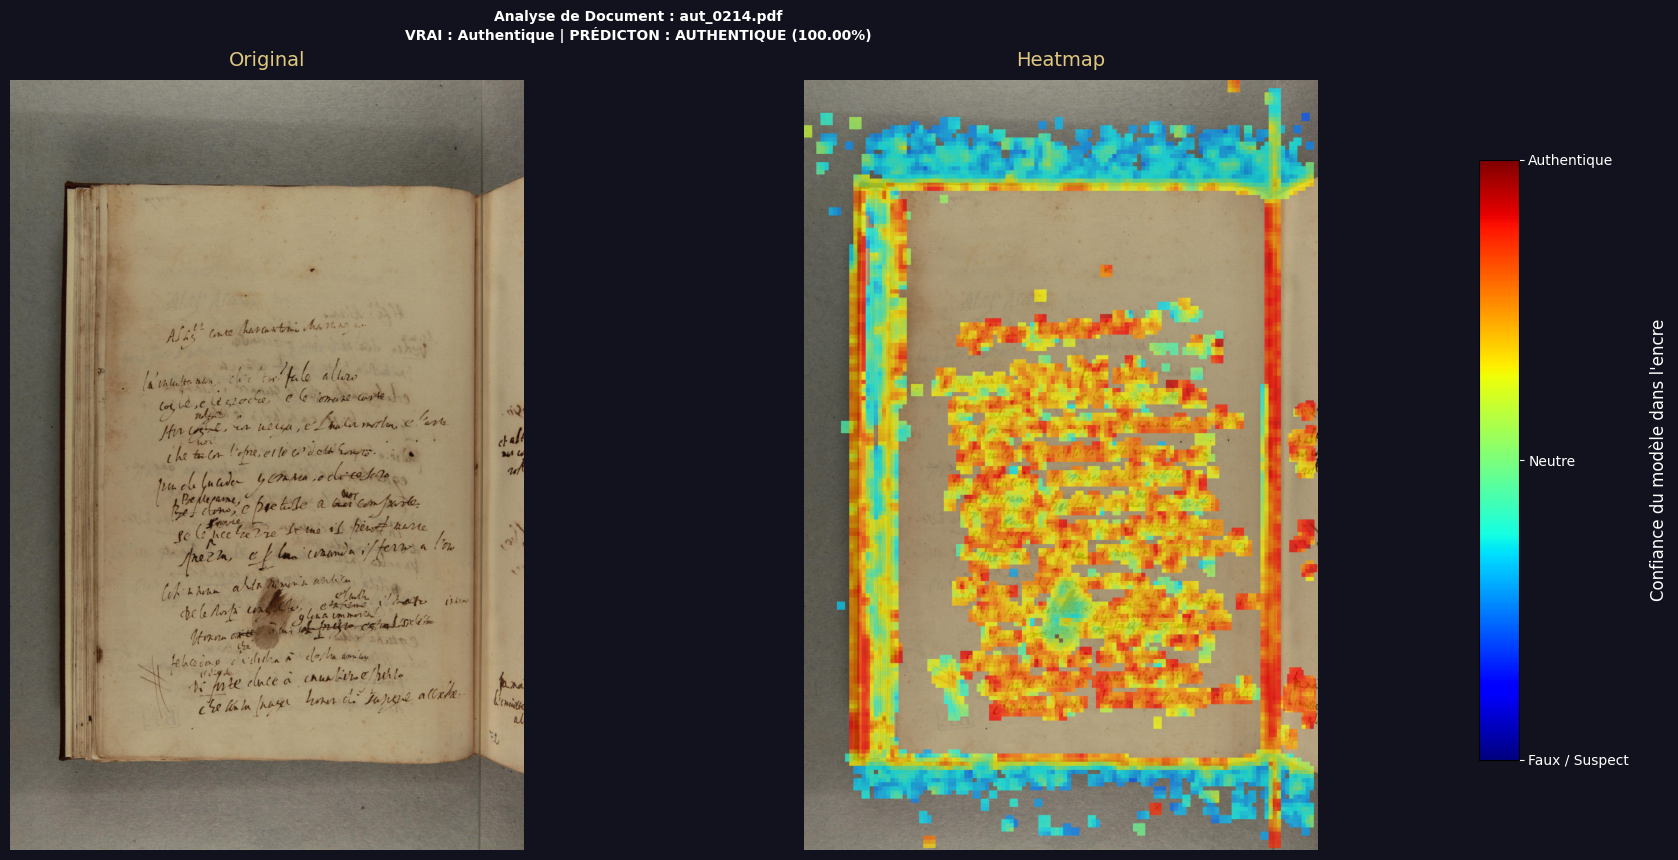

In [ ]:
import random
from matplotlib import pyplot as plt

# pdf et images
def load_image_robust(path: Path) -> Optional[np.ndarray]:
    """Charge une image depuis un chemin, avec support PDF et gestion d'erreurs."""
    if path.suffix.lower() == ".pdf":
        try:
            doc  = fitz.open(str(path))
            page = doc.load_page(0)
            pix  = page.get_pixmap(matrix=fitz.Matrix(2, 2))
            img_data = np.frombuffer(pix.samples, dtype=np.uint8).reshape(
                pix.h, pix.w, pix.n
            )
            image = cv2.cvtColor(img_data, cv2.COLOR_RGB2BGR)
            doc.close()
            return image
        except Exception as e:
            print(f"  [Erreur] Impossible de lire le PDF : {e}")
            return None
    else:
        image = cv2.imread(str(path))
        if image is None:
            print(f"  [Erreur] Impossible de lire l'image : {path}")
        return image

def visualize_comparison_dual(analyzer: ManuscriptAnalyzer, dataset_key: str):
    """Affiche une image originale et sa heatmap côte à côte pour un document aléatoire."""
    if analyzer._clf is None:
        print("Erreur : Le modèle doit être entraîné.")
        return

    # 1. Sélection d'un échantillon unique au hasard
    samples = DatasetLoader.load(dataset_key)
    img_path, true_label = random.choice(samples)
    img_bgr = load_image_robust(img_path)
    
    if img_bgr is None:
        print("Erreur de chargement de l'image.")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # 2. Analyse et Génération de la Heatmap
    gray, ink_mask = analyzer.isolator.isolate(img_bgr)
    blocks = analyzer.detector.detect(ink_mask)
    
    # Calcul des zones de zoom
    x_coords, y_coords = [b[0] for b in blocks], [b[1] for b in blocks]
    x_ends, y_ends = [b[0]+b[2] for b in blocks], [b[1]+b[3] for b in blocks]
    x1, y1 = max(0, min(x_coords)-50), max(0, min(y_coords)-50)
    x2, y2 = min(w, max(x_ends)+50), min(h, max(y_ends)+50)

    # Extraction et prédiction des patches
    ps, st = analyzer.cfg.patch_size, analyzer.cfg.patch_stride
    patch_feats, coords = [], []
    for (bx, by, bw, bh) in blocks:
        for py in range(0, bh - ps, st):
            for px in range(0, bw - ps, st):
                ax, ay = bx + px, by + py
                pm = ink_mask[ay : ay + ps, ax : ax + ps]
                if np.sum(pm > 0) / (ps * ps) >= analyzer.cfg.min_ink_ratio_in_patch:
                    pg = gray[ay : ay + ps, ax : ax + ps].copy()
                    pg[pm == 0] = 255
                    patch_feats.append(analyzer.featurizer.patch_features(pg))
                    coords.append((ax, ay))

    heatmap = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)

    if patch_feats:
        X_p_sc = analyzer._scaler.transform(np.tile(np.array(patch_feats), 4))
        probs = analyzer._clf.predict_proba(X_p_sc)[:, 1]
        for p_val, (x, y) in zip(probs, coords):
            heatmap[y:y+ps, x:x+ps] += p_val
            count[y:y+ps, x:x+ps] += 1
        heatmap = np.divide(heatmap, count, out=np.zeros_like(heatmap), where=count!=0)

    # 3. Préparation des visuels (Crops)
    img_crop = img_rgb[y1:y2, x1:x2]
    h_crop, c_crop = heatmap[y1:y2, x1:x2], count[y1:y2, x1:x2]
    
    # Création de l'overlay heatmap
    h_norm = (h_crop * 255).astype(np.uint8)
    h_color = cv2.applyColorMap(h_norm, cv2.COLORMAP_JET)
    h_color = cv2.cvtColor(h_color, cv2.COLOR_BGR2RGB)
    mask = (c_crop > 0)
    overlay = img_crop.copy()
    overlay[mask] = cv2.addWeighted(img_crop, 0.3, h_color, 0.7, 0)[mask]

    # 4. Affichage côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#12121f')
    
    # Titre général avec verdict
    prediction = analyzer.predict_file(str(img_path))
    verdict_color = '#4CAF50' if prediction['verdict'] == "AUTHENTIQUE" else '#F44336'
    fig.suptitle(f"Analyse de Document : {img_path.name}\n"
                 f"VRAI : {'Authentique' if true_label==1 else 'Faux'} | "
                 f"PRÉDICTON : {prediction['verdict']} ({prediction.get('proba_authentique',0):.2%})",
                 color='white', fontsize=10, fontweight='bold', y=0.95)

    # Original Zoomé
    axes[0].imshow(img_crop)
    axes[0].set_title("Original", color='#e0c97f', fontsize=14, pad=10)
    axes[0].axis('off')

    # Heatmap Zoomée
    axes[1].imshow(overlay)
    axes[1].set_title("Heatmap", color='#e0c97f', fontsize=14, pad=10)
    axes[1].axis('off')

    # 5. Légende Colorbar
    cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
    sm = plt.cm.ScalarMappable(cmap=plt.get_cmap('jet'), norm=plt.Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Confiance du modèle dans l'encre", color='white', size=12, labelpad=15)
    cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Faux / Suspect', 'Neutre', 'Authentique'])

    plt.subplots_adjust(wspace=0.05, right=0.9)
    plt.show()

# Utilisation
visualize_comparison_dual(model, "tasso")